In [195]:
%pip install vnpy
%pip install baostock
import vnpy
import baostock as bs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import akshare as ak
from zoneinfo import ZoneInfo
from vnpy.trader.object import BarData
from vnpy.trader.constant import Exchange, Interval
from vnpy.trader.database import get_database


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [196]:
df = pd.read_parquet("688981_5min_20200716-20260602.parquet")
df.head(100)

,code,open,high,low,close,volume,amount,adjustflag
datetime,,,,,,,,
2020-07-16 09:35:00,688981,95.0000000000,95.0000000000,83.0000000000,86.8600000000,158727622,14381175040.0000,2
2020-07-16 09:40:00,688981,86.0000000000,87.9800000000,80.0000000000,86.0000000000,59510624,5004495104.0000,2
2020-07-16 09:45:00,688981,86.0100000000,88.0000000000,84.9900000000,87.1300000000,36040553,3114025984.0000,2
2020-07-16 09:50:00,688981,87.0000000000,87.3000000000,85.2800000000,85.5000000000,14591281,1265563392.0000,2
2020-07-16 09:55:00,688981,85.5200000000,85.8500000000,85.3300000000,85.3500000000,13968256,1196435200.0000,2
...,...,...,...,...,...,...,...,...
2020-07-17 15:00:00,688981,77.1300000000,77.1700000000,77.0600000000,77.0600000000,4671325,360155904.0000,2
2020-07-20 09:35:00,688981,77.1900000000,77.2000000000,74.0000000000,75.2500000000,20643891,1558470720.0000,2
2020-07-20 09:40:00,688981,75.1100000000,75.1100000000,72.3000000000,72.6400000000,18952217,1392710480.0000,2


In [197]:
df.describe()

,code,open,high,low,close,volume,amount,adjustflag
count,68304,68304,68304,68304,68304,68304,68304,68304
unique,1,9084,9044,8939,9098,66020,67713,1
top,688981,0E-10,0E-10,0E-10,0E-10,0,0.0000,2
freq,68304,288,288,288,288,297,297,68304


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68304 entries, 2020-07-16 09:35:00 to 2026-06-01 15:00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   code        68304 non-null  object
 1   open        68304 non-null  object
 2   high        68304 non-null  object
 3   low         68304 non-null  object
 4   close       68304 non-null  object
 5   volume      68304 non-null  object
 6   amount      68304 non-null  object
 7   adjustflag  68304 non-null  object
dtypes: object(8)
memory usage: 4.7+ MB


In [199]:
float_cols = ["open", "high", "low", "close", "volume", "amount"]


# 这个errors的意思是遇到不能转换的格式，就变成NaN，而不是报错。
df[float_cols] = df[float_cols].apply(pd.to_numeric, errors="coerce")

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68304 entries, 2020-07-16 09:35:00 to 2026-06-01 15:00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   code        68304 non-null  object 
 1   open        68304 non-null  float64
 2   high        68304 non-null  float64
 3   low         68304 non-null  float64
 4   close       68304 non-null  float64
 5   volume      68304 non-null  int64  
 6   amount      68304 non-null  float64
 7   adjustflag  68304 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 4.7+ MB


In [201]:
# 特征工程-01-处理时间段问题（早晚、周末、节假日）

# =========================
# 交易日历
# =========================

# df = df.copy()
# df = df.sort_index()

# ## 确保索引是 datetime 类型
# if not isinstance(df.index, pd.DatetimeIndex):
#     df.index = pd.to_datetime(df.index)

# ## 构造交易日期
# df["trade_date"] = df.index.normalize()

# ## 构造交易日日历
# trade_dates = pd.Series(df["trade_date"].unique()).sort_values()
# calendar = pd.DataFrame({"trade_date": trade_dates})

# ## 上一个交易日
# calendar["prev_trade_date"] = calendar["trade_date"].shift(1)

# ## 当前交易日距离上一个交易日的自然日间隔
# calendar["gap_days"] = (
#     calendar["trade_date"] - calendar["prev_trade_date"]
# ).dt.days

# ## 是否普通连续交易日
# calendar["is_normal_day"] = (calendar["gap_days"] == 1).astype(int)

# ## 是否周末后
# calendar["is_after_weekend"] = (
#     (calendar["gap_days"] == 3) &
#     (calendar["trade_date"].dt.dayofweek == 0)
# ).astype(int)

# ## 是否长假后
# calendar["is_after_holiday"] = (calendar["gap_days"] > 3).astype(int)

# ## 合并前先删除旧的交易日历特征，避免重复运行时报错
# calendar_feature_cols = [
#     "gap_days",
#     "is_normal_day",
#     "is_after_weekend",
#     "is_after_holiday",
# ]

# df = df.drop(columns=[c for c in calendar_feature_cols if c in df.columns])

# ## 合并交易日历特征
# df = df.join(
#     calendar.set_index("trade_date")[
#         ["gap_days", "is_normal_day", "is_after_weekend", "is_after_holiday"]
#     ],
#     on="trade_date"
# )

# ## 缺失值填充
# df["gap_days"] = df["gap_days"].fillna(1)
# df["is_normal_day"] = df["is_normal_day"].fillna(1)
# df["is_after_weekend"] = df["is_after_weekend"].fillna(0)
# df["is_after_holiday"] = df["is_after_holiday"].fillna(0)

In [202]:
# =========================
# 特征工程
# =========================

# 首先这里重新从 raw_df 开始，避免重复运行 cell 之后产生重复列或者污染
df = df.copy()
df = df.sort_index()

# 如果索引不是时间索引，先转成时间索引
if not isinstance(df.index, pd.DatetimeIndex):
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.set_index("datetime")
    else:
        df.index = pd.to_datetime(df.index)

# 基础参数
EPS = 1e-12

WINDOWS = [1, 3, 5, 10, 20, 48]
SHORT_WINDOWS = [3, 5, 10, 20]
MID_WINDOWS = [5, 10, 20, 48]
LONG_WINDOWS = [20, 48]

# 交易日期
df["trade_date"] = df.index.normalize()

In [203]:
# =========================
# 收益率特征
# =========================

# 这里收益率都是用当前和过去的数据构造，不存在未来函数
df["ret_1"] = df["close"].pct_change(1)
df["log_close"] = np.log(df["close"] + EPS)

for w in WINDOWS:
    df[f"ret_{w}"] = df["close"].pct_change(w)
    df[f"log_ret_{w}"] = df["log_close"].diff(w)

In [204]:
# =========================
# 均线特征
# =========================

# 注意：ma_w 是绝对价格水平，只作为中间变量，不进入模型
# 真正进入模型的是 ma_dev、ma_slope、ma_gap 这种相对特征
for w in MID_WINDOWS:
    df[f"ma_{w}"] = df["close"].rolling(w).mean()
    df[f"ma_dev_{w}"] = df["close"] / (df[f"ma_{w}"] + EPS) - 1
    df[f"ma_slope_{w}"] = df[f"ma_{w}"] / (df[f"ma_{w}"].shift(1) + EPS) - 1

# 多周期均线偏离
df["ma_gap_5_20"] = df["ma_5"] / (df["ma_20"] + EPS) - 1
df["ma_gap_10_48"] = df["ma_10"] / (df["ma_48"] + EPS) - 1

In [205]:
# =========================
# 动量特征
# =========================

# 多周期动量差
df["mom_3_10"] = df["ret_3"] - df["ret_10"]
df["mom_5_20"] = df["ret_5"] - df["ret_20"]
df["mom_10_48"] = df["ret_10"] - df["ret_48"]

# 非重叠动量
df["ret_recent_3"] = df["close"] / (df["close"].shift(3) + EPS) - 1
df["ret_prev_3"] = df["close"].shift(3) / (df["close"].shift(6) + EPS) - 1
df["ret_prev_6"] = df["close"].shift(3) / (df["close"].shift(9) + EPS) - 1

df["mom_change_3"] = df["ret_recent_3"] - df["ret_prev_3"]
df["mom_change_6"] = df["ret_recent_3"] - df["ret_prev_6"]

# 上涨下跌K线比例
df["up_bar"] = (df["close"] > df["close"].shift(1)).astype(int)
df["down_bar"] = (df["close"] < df["close"].shift(1)).astype(int)

for w in SHORT_WINDOWS:
    df[f"up_ratio_{w}"] = df["up_bar"].rolling(w).mean()
    df[f"down_ratio_{w}"] = df["down_bar"].rolling(w).mean()

In [206]:
# =========================
# K线结构特征
# =========================

# K线实体
df["body"] = (df["close"] - df["open"]) / (df["open"] + EPS)

# K线振幅
df["bar_range"] = (df["high"] - df["low"]) / (df["close"] + EPS)

# 上影线和下影线
df["upper_shadow"] = (df["high"] - df[["open", "close"]].max(axis=1)) / (df["close"] + EPS)
df["lower_shadow"] = (df[["open", "close"]].min(axis=1) - df["low"]) / (df["close"] + EPS)

# 收盘价在K线内部的位置
df["close_position"] = (df["close"] - df["low"]) / (df["high"] - df["low"] + EPS)

In [207]:
# =========================
# 波动率特征
# =========================

# 收益率波动率
for w in MID_WINDOWS:
    df[f"vol_{w}"] = df["ret_1"].rolling(w).std()

# 振幅波动率
for w in MID_WINDOWS:
    df[f"range_mean_{w}"] = df["bar_range"].rolling(w).mean()
    df[f"range_vol_{w}"] = df["bar_range"].rolling(w).std()

# Parkinson 波动率
hl = np.log((df["high"] + EPS) / (df["low"] + EPS)) ** 2

for w in MID_WINDOWS:
    df[f"parkinson_vol_{w}"] = np.sqrt(hl.rolling(w).mean() / (4 * np.log(2)))

# 波动率比值
df["vol_ratio_5_20"] = df["vol_5"] / (df["vol_20"] + EPS)
df["vol_ratio_10_48"] = df["vol_10"] / (df["vol_48"] + EPS)

# 波动率标准化动量
df["mom_z_3_20"] = df["ret_3"] / (df["vol_20"] + EPS)
df["mom_z_5_20"] = df["ret_5"] / (df["vol_20"] + EPS)
df["mom_z_10_48"] = df["ret_10"] / (df["vol_48"] + EPS)

# 波动率 zscore
for i in [5, 10, 20]:
    for w in [20, 48]:
        vol_mean = df[f"vol_{i}"].rolling(w).mean()
        vol_std = df[f"vol_{i}"].rolling(w).std()
        df[f"vol_zscore_{i}_{w}"] = (df[f"vol_{i}"] - vol_mean) / (vol_std + EPS)

In [208]:
# =========================
# VWAP 特征
# =========================
df = df.copy()
# 单根K线 VWAP
df["vwap_bar"] = df["amount"] / (df["volume"] + EPS)
df["vwap_bar"] = df["vwap_bar"].fillna(df["close"])

# 单根K线 VWAP 偏离
df["vwap_bar_dev"] = df["close"] / (df["vwap_bar"] + EPS) - 1

# 日内累计 VWAP
df["amount_cum_day"] = df.groupby("trade_date")["amount"].cumsum()
df["volume_cum_day"] = df.groupby("trade_date")["volume"].cumsum()

df["vwap_cum_day"] = df["amount_cum_day"] / (df["volume_cum_day"] + EPS)
df["vwap_cum_day"] = df["vwap_cum_day"].fillna(df["close"])

# 日内 VWAP 偏离
df["vwap_dev_day"] = df["close"] / (df["vwap_cum_day"] + EPS) - 1

# 日内 VWAP 斜率
df["vwap_cum_slope_3"] = df["vwap_cum_day"] / (df["vwap_cum_day"].shift(3) + EPS) - 1
df["vwap_cum_slope_6"] = df["vwap_cum_day"] / (df["vwap_cum_day"].shift(6) + EPS) - 1

# 滚动 VWAP
# 注意：vwap_roll_w 是绝对价格水平，只作为中间变量，不进入模型
for w in MID_WINDOWS:
    amount_roll = df["amount"].rolling(w).sum()
    volume_roll = df["volume"].rolling(w).sum()
    
    df[f"vwap_roll_{w}"] = amount_roll / (volume_roll + EPS)
    df[f"vwap_roll_{w}"] = df[f"vwap_roll_{w}"].fillna(df["close"])
    
    df[f"vwap_roll_dev_{w}"] = df["close"] / (df[f"vwap_roll_{w}"] + EPS) - 1
    df[f"vwap_roll_slope_{w}"] = df[f"vwap_roll_{w}"] / (df[f"vwap_roll_{w}"].shift(1) + EPS) - 1

# 滚动VWAP和日内VWAP的相对差
df["vwap_spread_20_day"] = df["vwap_roll_20"] / (df["vwap_cum_day"] + EPS) - 1
df["vwap_spread_48_day"] = df["vwap_roll_48"] / (df["vwap_cum_day"] + EPS) - 1

In [209]:
# =========================
# CLV 特征
# =========================

# CLV 衡量收盘价在K线区间中的强弱
df["clv"] = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / (df["high"] - df["low"] + EPS)
df["clv"] = df["clv"].clip(-1, 1)

for w in MID_WINDOWS:
    df[f"clv_mean_{w}"] = df["clv"].rolling(w).mean()
    df[f"clv_sum_{w}"] = df["clv"].rolling(w).sum()

# 成交量加权 CLV
df["clv_volume"] = df["clv"] * np.log1p(df["volume"])

for w in MID_WINDOWS:
    df[f"clv_volume_sum_{w}"] = df["clv_volume"].rolling(w).sum()
    df[f"clv_volume_mean_{w}"] = df["clv_volume"].rolling(w).mean()

# ADL rolling normalized
df["money_flow_volume"] = df["clv"] * df["volume"]

for w in [10, 20, 48]:
    mfv_sum = df["money_flow_volume"].rolling(w).sum()
    vol_sum = df["volume"].rolling(w).sum()
    df[f"adl_roll_norm_{w}"] = mfv_sum / (vol_sum + EPS)

In [210]:
# =========================
# 成交量和成交额特征
# =========================

# 注意：volume_ma 和 amount_ma 只作为中间变量，不进入模型
# 真正进入模型的是 ratio / log_ratio / direction 这类相对特征
for w in MID_WINDOWS:
    df[f"volume_ma_{w}"] = df["volume"].rolling(w).mean()
    df[f"amount_ma_{w}"] = df["amount"].rolling(w).mean()
    
    df[f"volume_ratio_{w}"] = df["volume"] / (df[f"volume_ma_{w}"] + EPS)
    df[f"amount_ratio_{w}"] = df["amount"] / (df[f"amount_ma_{w}"] + EPS)
    
    df[f"log_volume_ratio_{w}"] = np.log1p(df["volume"]) - np.log1p(df[f"volume_ma_{w}"])
    df[f"log_amount_ratio_{w}"] = np.log1p(df["amount"]) - np.log1p(df[f"amount_ma_{w}"])

# 成交量变化率
df["volume_change"] = df["volume"] / (df["volume"].shift(1) + EPS) - 1
df["amount_change"] = df["amount"] / (df["amount"].shift(1) + EPS) - 1

# 收益率和成交量结合
df["ret_volume"] = df["ret_1"] * np.log1p(df["volume"])
df["ret_amount"] = df["ret_1"] * np.log1p(df["amount"])

for w in [5, 10, 20]:
    df[f"ret_volume_sum_{w}"] = df["ret_volume"].rolling(w).sum()
    df[f"ret_amount_sum_{w}"] = df["ret_amount"].rolling(w).sum()

In [211]:
# =========================
# 成交量方向确认特征
# =========================
df = df.copy()
# 这里重点解决原来模型只学绝对成交量的问题
# signed_volume / signed_amount 带有方向信息
df["signed_volume"] = np.sign(df["ret_1"]) * np.log1p(df["volume"])
df["signed_amount"] = np.sign(df["ret_1"]) * np.log1p(df["amount"])

for w in [5, 10, 20, 48]:
    df[f"signed_volume_sum_{w}"] = df["signed_volume"].rolling(w).sum()
    df[f"signed_amount_sum_{w}"] = df["signed_amount"].rolling(w).sum()
    df[f"signed_volume_mean_{w}"] = df["signed_volume"].rolling(w).mean()
    df[f"signed_amount_mean_{w}"] = df["signed_amount"].rolling(w).mean()

# 放量上涨 / 放量下跌
df["up_volume_ratio"] = df["up_bar"] * df["volume_ratio_20"]
df["down_volume_ratio"] = df["down_bar"] * df["volume_ratio_20"]

df["up_amount_ratio"] = df["up_bar"] * df["amount_ratio_20"]
df["down_amount_ratio"] = df["down_bar"] * df["amount_ratio_20"]

for w in [5, 10, 20]:
    df[f"up_volume_ratio_mean_{w}"] = df["up_volume_ratio"].rolling(w).mean()
    df[f"down_volume_ratio_mean_{w}"] = df["down_volume_ratio"].rolling(w).mean()
    df[f"up_amount_ratio_mean_{w}"] = df["up_amount_ratio"].rolling(w).mean()
    df[f"down_amount_ratio_mean_{w}"] = df["down_amount_ratio"].rolling(w).mean()

In [212]:
# =========================
# 日内结构特征
# =========================

# bar_in_day 表示当前是当天第几根K线
df["bar_in_day"] = df.groupby("trade_date").cumcount()

# 每天总K线数量
df["bars_in_day"] = df.groupby("trade_date")["close"].transform("count")

# 日内位置百分比
df["bar_in_day_pct"] = df["bar_in_day"] / (df["bars_in_day"] - 1 + EPS)

# 上午 / 下午
df["is_morning"] = (
    (df.index.time >= pd.Timestamp("09:30").time()) &
    (df.index.time <= pd.Timestamp("11:30").time())
).astype(int)

df["is_afternoon"] = (
    (df.index.time >= pd.Timestamp("13:00").time()) &
    (df.index.time <= pd.Timestamp("15:00").time())
).astype(int)

# 开盘30分钟、收盘30分钟、午盘开盘
df["is_open_30min"] = (df["bar_in_day"] < 6).astype(int)
df["is_close_30min"] = (df["bar_in_day"] >= df["bars_in_day"] - 6).astype(int)

df["is_after_lunch_open"] = (
    (df.index.time >= pd.Timestamp("13:00").time()) &
    (df.index.time <= pd.Timestamp("13:30").time())
).astype(int)

In [213]:
# =========================
# 交易日历特征
# =========================

trade_dates = pd.Series(df["trade_date"].unique()).sort_values()

calendar = pd.DataFrame({
    "trade_date": trade_dates
})

calendar["prev_trade_date"] = calendar["trade_date"].shift(1)
calendar["gap_days"] = (calendar["trade_date"] - calendar["prev_trade_date"]).dt.days

calendar["gap_days"] = calendar["gap_days"].fillna(1)

# 连续交易日
calendar["is_normal_day"] = (calendar["gap_days"] == 1).astype(int)

# 周末后第一个交易日
calendar["is_after_weekend"] = (
    (calendar["gap_days"] == 3) &
    (calendar["trade_date"].dt.dayofweek == 0)
).astype(int)

# 长假后第一个交易日
calendar["is_after_holiday"] = (calendar["gap_days"] > 3).astype(int)

# 防止重复运行 join 后同名列冲突
calendar_feature_cols = [
    "gap_days",
    "is_normal_day",
    "is_after_weekend",
    "is_after_holiday"
]

df = df.drop(columns=[c for c in calendar_feature_cols if c in df.columns])

df = df.join(
    calendar.set_index("trade_date")[calendar_feature_cols],
    on="trade_date"
)

df[calendar_feature_cols] = df[calendar_feature_cols].fillna(0)

In [214]:
# =========================
# 同时刻成交量相对特征
# =========================

# 注意：same_bar_mean 是绝对成交量/成交额均值，只作为中间变量，不进入模型
# 使用 shift(1)，避免当前样本进入自身的历史均值
df["volume_same_bar_mean_20d"] = (
    df.groupby("bar_in_day")["volume"]
    .transform(lambda x: x.shift(1).rolling(20, min_periods=5).mean())
)

df["amount_same_bar_mean_20d"] = (
    df.groupby("bar_in_day")["amount"]
    .transform(lambda x: x.shift(1).rolling(20, min_periods=5).mean())
)

df["volume_same_bar_ratio"] = df["volume"] / (df["volume_same_bar_mean_20d"] + EPS)
df["amount_same_bar_ratio"] = df["amount"] / (df["amount_same_bar_mean_20d"] + EPS)

df["log_volume_same_bar_ratio"] = np.log1p(df["volume"]) - np.log1p(df["volume_same_bar_mean_20d"])
df["log_amount_same_bar_ratio"] = np.log1p(df["amount"]) - np.log1p(df["amount_same_bar_mean_20d"])

In [215]:
# =========================
# 均值回归特征
# =========================

for w in [10, 20, 48]:
    price_mean = df["close"].rolling(w).mean()
    price_std = df["close"].rolling(w).std()
    df[f"price_zscore_{w}"] = (df["close"] - price_mean) / (price_std + EPS)

# 日内高低点位置
df["cum_high_day"] = df.groupby("trade_date")["high"].cummax()
df["cum_low_day"] = df.groupby("trade_date")["low"].cummin()

df["intraday_range_position"] = (
    (df["close"] - df["cum_low_day"]) /
    (df["cum_high_day"] - df["cum_low_day"] + EPS)
)

In [216]:
# =========================
# 流动性特征
# =========================

# Amihud 流动性冲击
df["amihud"] = df["ret_1"].abs() / (df["amount"] + EPS)

for w in [10, 20, 48]:
    df[f"amihud_{w}"] = df["amihud"].rolling(w).mean()

# 单位成交量对应振幅
df["range_per_volume"] = df["bar_range"] / (df["volume"] + EPS)

for w in [10, 20, 48]:
    df[f"range_per_volume_{w}"] = df["range_per_volume"].rolling(w).mean()

In [217]:
# =========================
# 缺失值和无穷值处理
# =========================

# 先把无穷值替换成缺失值
df = df.replace([np.inf, -np.inf], np.nan)

# 删除因为 rolling / shift 产生的缺失值
df = df.dropna().copy()

# 整理 DataFrame 内存碎片
df = df.copy()

print("特征工程后数据量:", df.shape)

特征工程后数据量: (67710, 230)


In [ ]:
# =========================
# MVP 全局参数与标签构造
# =========================

# 当前 MVP 先收窄问题定义：
# 1) 只做一个二分类标签：未来 HORIZON 根K线收益是否覆盖交易成本和滑点。
# 2) 不再同时维护多套 label，避免训练目标漂移。
# 3) 模型、数据窗口、成本参数统一从 MVP_CONFIG 读取。

MVP_CONFIG = {
    "symbol": "688981",
    "bar_minutes": 5,
    "horizon": 3,                 # 预测未来3根5分钟K线，也就是未来15分钟
    "lookback": 32,               # 使用过去32根5分钟K线，也就是过去160分钟
    "commission_rate": 0.001,     # 佣金 0.10%
    "slippage_rate": 0.0005,      # 滑点 0.05%
    "one_side_cost": None,        # 下面自动计算：佣金 + 滑点
    "round_trip_cost": None,      # 下面自动计算：买入卖出双边成本
    "target_col": "label_round_trip_net",
    "sequence_mode": "continuous",
    "train_ratio": 0.70,
    "valid_ratio": 0.15,
    "batch_size_train": 128,
    "batch_size_eval": 256,
    "lstm_hidden_dim": 256,
    "lstm_num_layers": 2,
    "lstm_dropout": 0.3,
    "cnn_channels": 64,
    "cnn_kernel_size": 3,
    "mlp_hidden_dim": 256,
    "mlp_dropout": 0.3,
    "learning_rate": 5e-4,
    "weight_decay": 1e-6,
    "max_epochs": 100,
    "early_stop_patience": 10,
    "grad_clip_norm": 1.0,
    "rf_n_estimators": 300,
    "rf_max_depth": 8,
    "rf_min_samples_leaf": 50,
    "random_state": 42,
}

HORIZON = MVP_CONFIG["horizon"]
COMMISSION_RATE = MVP_CONFIG["commission_rate"]
SLIPPAGE_RATE = MVP_CONFIG["slippage_rate"]
ONE_SIDE_COST = COMMISSION_RATE + SLIPPAGE_RATE
ROUND_TRIP_COST = 2 * ONE_SIDE_COST
TOTAL_COST = ONE_SIDE_COST
LABEL_THRESHOLD = ROUND_TRIP_COST

MVP_CONFIG["one_side_cost"] = ONE_SIDE_COST
MVP_CONFIG["round_trip_cost"] = ROUND_TRIP_COST


# =========================
# 未来收益率
# =========================

# 未来 HORIZON 根K线后的收盘价
df["future_close"] = df["close"].shift(-HORIZON)

# 未来 HORIZON 根K线 close-to-close 收益率，仅用于行情诊断。
df["future_return"] = df["future_close"] / df["close"] - 1

# 可执行交易收益：当前K线收盘后产生信号，下一根K线开盘买入，HORIZON对应K线收盘卖出。
# 这个收益口径和后面的真实事件回测一致。
df["future_entry_open"] = df["open"].shift(-1)
df["trade_return"] = df["future_close"] / df["future_entry_open"] - 1

# 未来 HORIZON 根K线对数收益率，仅作为诊断备用，不作为标签。
df["future_log_return"] = np.log(df["future_close"] / df["close"])

# 下一根K线收益率，用于后续如果要做逐bar回测时备用。
df["next_ret_1"] = df["close"].shift(-1) / df["close"] - 1


# =========================
# 唯一主标签：成本后可交易上涨
# =========================

# label_round_trip_net = 1 表示未来可执行交易收益超过买入+卖出双边成本。
# 当前 MVP 不再同时维护方向标签、动态波动标签、三分类标签或止盈止损标签。
df[MVP_CONFIG["target_col"]] = (df["trade_return"] > LABEL_THRESHOLD).astype(int)


# =========================
# 标签检查
# =========================

print("MVP_CONFIG:")
print(pd.Series(MVP_CONFIG))

print("\n单边成本 ONE_SIDE_COST:", ONE_SIDE_COST)
print("往返成本 LABEL_THRESHOLD:", LABEL_THRESHOLD)
print("\nlabel_round_trip_net 分布：")
print(df[MVP_CONFIG["target_col"]].value_counts(normalize=True))

print("\nlabel=1 对应 trade_return 描述：")
print(df.loc[df[MVP_CONFIG["target_col"]] == 1, "trade_return"].describe())

print("\nlabel=0 对应 trade_return 描述：")
print(df.loc[df[MVP_CONFIG["target_col"]] == 0, "trade_return"].describe())


# =========================
# 缺失值处理
# =========================

# 因为标签用了 shift(-HORIZON)，最后 HORIZON 行没有未来数据，需要删除。
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().copy()

# 整理 DataFrame 内存碎片。
df = df.copy()






In [ ]:
# =========================
# 特征选择
# =========================

# 不进入模型的字段
exclude_cols = [
    # 原始价格和成交量水平
    "open",
    "high",
    "low",
    "close",
    "volume",
    "amount",
    
    # 时间和日期字段
    "trade_date",
    
    # 绝对价格水平和中间变量
    "log_close",
    "vwap_bar",
    "vwap_cum_day",
    "amount_cum_day",
    "volume_cum_day",
    "cum_high_day",
    "cum_low_day",
    
    # CLV / ADL 中间变量
    "money_flow_volume",
]

# 如果后面已经构造了标签，也要排除
target_cols = [
    # 当前 MVP 唯一主标签
    "label_round_trip_net",
    "label_cost_net",

    # 历史实验中可能残留的旧标签，统一排除，避免未来函数进入特征。
    "label",
    "label_cost_adjusted",
    "label_3class",
    "label_dynamic_3class",
    "label_dynamic_binary",
    "label_trade_success",
    "label_net_up",
    "label_path_up",
    "label_quality_up",
    "label_down",
    "label_path_down",

    # 未来收益
    "future_return",
    "future_log_return",
    "future_max_return",
    "future_min_return",
    "next_ret_1",
    "trade_return",

    # 未来价格
    "future_close",
    "future_entry_open",
    "future_max_close",
    "future_min_close",
    "future_max_price",
    "future_min_price",

    # 止盈止损未来触发结果
    "hit_take_profit",
    "hit_stop_loss",

    # 动态标签辅助变量
    "target_vol",
    "dynamic_up_threshold",
    "dynamic_down_threshold",
]

exclude_cols = exclude_cols + [c for c in target_cols if c in df.columns]

# 初步选择数值型特征
feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(df[c])
]




In [220]:
df.head()

,code,open,high,low,close,volume,amount,adjustflag,trade_date,ret_1,...,label_dynamic_3class,label_dynamic_binary,next_ret_1,future_max_close,future_max_return,future_min_close,future_min_return,hit_take_profit,hit_stop_loss,label_trade_success
datetime,,,,,,,,,,,,,,,,,,,,,
2020-07-23 09:35:00,688981,78.01,79.33,77.90,79.20,8071958,633734960.0,2,2020-07-23,-0.004650,...,0,0,-0.008333,79.50,0.003788,78.54,-0.008333,1,1,0
2020-07-23 09:40:00,688981,79.17,79.24,78.29,78.54,3505787,276230000.0,2,2020-07-23,-0.008333,...,0,0,0.005984,79.50,0.012223,78.77,0.002928,1,0,1
2020-07-23 09:45:00,688981,78.57,79.29,78.50,79.01,3100370,244783104.0,2,2020-07-23,0.005984,...,-1,0,0.006202,79.50,0.006202,77.90,-0.014049,1,1,0
2020-07-23 09:50:00,688981,79.00,79.72,78.96,79.50,3239010,257448176.0,2,2020-07-23,0.006202,...,-1,0,-0.009182,78.77,-0.009182,77.88,-0.020377,0,1,0
2020-07-23 09:55:00,688981,79.49,79.49,78.77,78.77,2561446,202545680.0,2,2020-07-23,-0.009182,...,-1,0,-0.011045,77.90,-0.011045,77.05,-0.021836,0,1,0


In [221]:
# =========================
# 删除绝对水平类特征
# =========================

remove_cols = []

for c in feature_cols:
    
    # 删除绝对成交量均值
    if c.startswith("volume_ma_"):
        remove_cols.append(c)
    
    # 删除绝对成交额均值
    if c.startswith("amount_ma_"):
        remove_cols.append(c)
    
    # 删除同时刻绝对成交量均值
    if c.startswith("volume_same_bar_mean_"):
        remove_cols.append(c)
    
    # 删除同时刻绝对成交额均值
    if c.startswith("amount_same_bar_mean_"):
        remove_cols.append(c)
    
    # 删除绝对均线水平，只保留 ma_dev / ma_slope / ma_gap
    if (
        c.startswith("ma_") and
        not c.startswith("ma_dev_") and
        not c.startswith("ma_slope_") and
        not c.startswith("ma_gap_")
    ):
        remove_cols.append(c)
    
    # 删除绝对 VWAP 水平，只保留 dev / slope / spread
    if (
        c.startswith("vwap_roll_") and
        not c.startswith("vwap_roll_dev_") and
        not c.startswith("vwap_roll_slope_")
    ):
        remove_cols.append(c)

remove_cols = sorted(list(set(remove_cols)))

print("删除绝对水平类特征数量:", len(remove_cols))
print(remove_cols)

feature_cols = [c for c in feature_cols if c not in remove_cols]

删除绝对水平类特征数量: 18
['amount_ma_10', 'amount_ma_20', 'amount_ma_48', 'amount_ma_5', 'amount_same_bar_mean_20d', 'ma_10', 'ma_20', 'ma_48', 'ma_5', 'volume_ma_10', 'volume_ma_20', 'volume_ma_48', 'volume_ma_5', 'volume_same_bar_mean_20d', 'vwap_roll_10', 'vwap_roll_20', 'vwap_roll_48', 'vwap_roll_5']


In [222]:
# =========================
# 删除疑似未来函数字段
# =========================

leak_keywords = [
    "future",
    "label",
    "target",
    "next",
    "hit",
]

leak_cols = [
    c for c in feature_cols
    if any(k in c.lower() for k in leak_keywords)
]

print("疑似未来函数字段：")
print(leak_cols)

# 如果存在疑似未来字段，直接从特征中删除
feature_cols = [c for c in feature_cols if c not in leak_cols]

疑似未来函数字段：
[]


In [223]:
# =========================
# 删除常数特征
# =========================

nunique = df[feature_cols].nunique()
constant_cols = [c for c in feature_cols if nunique[c] <= 1]

print("常数特征数量:", len(constant_cols))
print(constant_cols)

feature_cols = [c for c in feature_cols if c not in constant_cols]

print("最终特征数量:", len(feature_cols))
print(feature_cols)

常数特征数量: 1
['bars_in_day']
最终特征数量: 194
['ret_1', 'log_ret_1', 'ret_3', 'log_ret_3', 'ret_5', 'log_ret_5', 'ret_10', 'log_ret_10', 'ret_20', 'log_ret_20', 'ret_48', 'log_ret_48', 'ma_dev_5', 'ma_slope_5', 'ma_dev_10', 'ma_slope_10', 'ma_dev_20', 'ma_slope_20', 'ma_dev_48', 'ma_slope_48', 'ma_gap_5_20', 'ma_gap_10_48', 'mom_3_10', 'mom_5_20', 'mom_10_48', 'ret_recent_3', 'ret_prev_3', 'ret_prev_6', 'mom_change_3', 'mom_change_6', 'up_bar', 'down_bar', 'up_ratio_3', 'down_ratio_3', 'up_ratio_5', 'down_ratio_5', 'up_ratio_10', 'down_ratio_10', 'up_ratio_20', 'down_ratio_20', 'body', 'bar_range', 'upper_shadow', 'lower_shadow', 'close_position', 'vol_5', 'vol_10', 'vol_20', 'vol_48', 'range_mean_5', 'range_vol_5', 'range_mean_10', 'range_vol_10', 'range_mean_20', 'range_vol_20', 'range_mean_48', 'range_vol_48', 'parkinson_vol_5', 'parkinson_vol_10', 'parkinson_vol_20', 'parkinson_vol_48', 'vol_ratio_5_20', 'vol_ratio_10_48', 'mom_z_3_20', 'mom_z_5_20', 'mom_z_10_48', 'vol_zscore_5_20', 'vol_

In [ ]:
# =========================
# 时间序列切分
# =========================

# 当前 MVP 唯一目标：未来 HORIZON 根K线收益率是否超过交易成本和滑点。
target_col = MVP_CONFIG["target_col"]

assert target_col in df.columns, f"target_col 不存在: {target_col}"

df_model = df.copy()
df_model = df_model.sort_index()

n = len(df_model)

train_end = int(n * MVP_CONFIG["train_ratio"])
valid_end = int(n * (MVP_CONFIG["train_ratio"] + MVP_CONFIG["valid_ratio"]))

train_df = df_model.iloc[:train_end].copy()
valid_df = df_model.iloc[train_end:valid_end].copy()
test_df = df_model.iloc[valid_end:].copy()

print("当前 target_col:", target_col)
print("标签定义: trade_return > ROUND_TRIP_COST")
print("ROUND_TRIP_COST:", ROUND_TRIP_COST)
print("训练集：", train_df.index.min(), train_df.index.max(), train_df.shape)
print("验证集：", valid_df.index.min(), valid_df.index.max(), valid_df.shape)
print("测试集：", test_df.index.min(), test_df.index.max(), test_df.shape)

print("训练集标签分布：")
print(train_df[target_col].value_counts(normalize=True))

print("验证集标签分布：")
print(valid_df[target_col].value_counts(normalize=True))

print("测试集标签分布：")
print(test_df[target_col].value_counts(normalize=True))






In [ ]:
# =========================
# Label 诊断并导出
# =========================

# 当前 MVP 只保留一个标签：label_round_trip_net。
# 诊断重点：样本分布是否过于失衡，以及 label=1 的可执行交易收益是否确实覆盖成本。

from pathlib import Path
import json

LABEL_DIAG_DIR = Path("outputs/diagnostics")
LABEL_DIAG_DIR.mkdir(parents=True, exist_ok=True)

candidate_label_cols = [target_col]

split_frames = {
    "all": df_model,
    "train": train_df,
    "valid": valid_df,
    "test": test_df,
}

label_summary_rows = []
label_class_rows = []
label_return_rows = []

for label_col in candidate_label_cols:
    for split_name, part in split_frames.items():
        s = part[label_col].dropna()
        value_counts = s.value_counts().sort_index()
        value_ratio = s.value_counts(normalize=True).sort_index()

        row = {
            "label_col": label_col,
            "split": split_name,
            "definition": "trade_return > 2 * (commission_rate + slippage_rate)",
            "threshold": float(ROUND_TRIP_COST),
            "sample_count": int(len(s)),
            "n_classes": int(s.nunique()),
            "positive_rate": float(s.mean()),
            "trade_return_mean_all": float(part["trade_return"].mean()),
        }

        if (s == 1).any():
            row["trade_return_mean_label_1"] = float(part.loc[s.index[s == 1], "trade_return"].mean())
            row["trade_return_median_label_1"] = float(part.loc[s.index[s == 1], "trade_return"].median())
        else:
            row["trade_return_mean_label_1"] = None
            row["trade_return_median_label_1"] = None

        label_summary_rows.append(row)

        for cls, cnt in value_counts.items():
            label_class_rows.append({
                "label_col": label_col,
                "split": split_name,
                "class": int(cls),
                "count": int(cnt),
                "ratio": float(value_ratio.loc[cls]),
            })

        for cls in value_counts.index:
            cls_ret = part.loc[part[label_col] == cls, "trade_return"]
            label_return_rows.append({
                "label_col": label_col,
                "split": split_name,
                "class": int(cls),
                "trade_return_mean": float(cls_ret.mean()),
                "trade_return_median": float(cls_ret.median()),
                "trade_return_std": float(cls_ret.std()),
            })

label_summary = pd.DataFrame(label_summary_rows)
label_class_distribution = pd.DataFrame(label_class_rows)
label_return_by_class = pd.DataFrame(label_return_rows)

label_summary.to_csv(LABEL_DIAG_DIR / "label_summary.csv", index=False)
label_class_distribution.to_csv(LABEL_DIAG_DIR / "label_class_distribution.csv", index=False)
label_return_by_class.to_csv(LABEL_DIAG_DIR / "label_return_by_class.csv", index=False)

label_diag_summary = {
    "candidate_label_cols": candidate_label_cols,
    "current_target_col": target_col,
    "definition": "trade_return > 2 * (commission_rate + slippage_rate)",
    "threshold": float(ROUND_TRIP_COST),
    "output_files": {
        "label_summary": str(LABEL_DIAG_DIR / "label_summary.csv"),
        "label_class_distribution": str(LABEL_DIAG_DIR / "label_class_distribution.csv"),
        "label_return_by_class": str(LABEL_DIAG_DIR / "label_return_by_class.csv"),
    }
}

with open(LABEL_DIAG_DIR / "label_diagnostics_summary.json", "w", encoding="utf-8") as f:
    json.dump(label_diag_summary, f, ensure_ascii=False, indent=2)

print("当前 target_col:", target_col)
print("Label 诊断结果已保存到:", LABEL_DIAG_DIR)

display(label_summary)
display(label_class_distribution)
display(label_return_by_class)







## MVP 当前实验设定

当前阶段先不做多 label、多窗口和跨日消融，主线固定为：

```text
LOOKBACK = 32
HORIZON = 3
target_col = label_round_trip_net
label 定义 = trade_return > 2 * (commission_rate + slippage_rate)
sequence_mode = continuous
```

也就是：用过去 160 分钟的序列，预测未来可执行交易收益是否能覆盖交易成本和滑点。

后续优化顺序：

```text
1. 先固定这个唯一标签，把模型训练和回测口径跑通
2. 再整理真实持仓回测逻辑
3. 最后再考虑窗口、跨日、Transformer-LSTM、Optuna 等扩展
```





In [ ]:
# =========================
# 当前 MVP 实验配置表
# =========================

experiment_grid = pd.DataFrame([
    {
        "lookback": MVP_CONFIG["lookback"],
        "horizon": MVP_CONFIG["horizon"],
        "target_col": MVP_CONFIG["target_col"],
        "label_definition": "trade_return > 2 * (commission_rate + slippage_rate)",
        "round_trip_cost": ROUND_TRIP_COST,
        "sequence_mode": MVP_CONFIG["sequence_mode"],
        "status": "active",
    }
])

experiment_grid["lookback_minutes"] = experiment_grid["lookback"] * MVP_CONFIG["bar_minutes"]
experiment_grid["horizon_minutes"] = experiment_grid["horizon"] * MVP_CONFIG["bar_minutes"]

Path("outputs/diagnostics").mkdir(parents=True, exist_ok=True)
experiment_grid.to_csv("outputs/diagnostics/experiment_grid_plan.csv", index=False)

print("当前 MVP 实验配置:")
display(experiment_grid)





In [225]:
# =========================
# 用训练集分位数缩尾
# =========================

# 这里不能用全样本分位数，否则会有轻微信息泄露
clip_bounds = {}

for c in feature_cols:
    lower = train_df[c].quantile(0.001)
    upper = train_df[c].quantile(0.999)
    clip_bounds[c] = (lower, upper)

for c in feature_cols:
    lower, upper = clip_bounds[c]
    
    train_df[c] = train_df[c].clip(lower, upper)
    valid_df[c] = valid_df[c].clip(lower, upper)
    test_df[c] = test_df[c].clip(lower, upper)

print("缩尾完成")

缩尾完成


In [226]:
# =========================
# 特征量纲检测：标准化前
# =========================

# 目的：检查是否存在极端量纲、近似常数、异常值比例过高的特征。
# 注意：这里只使用训练集统计，避免测试集信息泄露。

raw_feature_check = train_df[feature_cols].copy()

pre_scale_report = pd.DataFrame({
    "dtype": raw_feature_check.dtypes.astype(str),
    "missing_rate": raw_feature_check.isna().mean(),
    "inf_count": np.isinf(raw_feature_check.replace([np.inf, -np.inf], np.nan)).sum(),
    "mean": raw_feature_check.mean(numeric_only=True),
    "std": raw_feature_check.std(numeric_only=True),
    "min": raw_feature_check.min(numeric_only=True),
    "p01": raw_feature_check.quantile(0.01),
    "p50": raw_feature_check.quantile(0.50),
    "p99": raw_feature_check.quantile(0.99),
    "max": raw_feature_check.max(numeric_only=True),
    "abs_max": raw_feature_check.abs().max(numeric_only=True),
    "nunique": raw_feature_check.nunique(),
})

pre_scale_report["range_p99_p01"] = pre_scale_report["p99"] - pre_scale_report["p01"]
pre_scale_report["cv_abs"] = pre_scale_report["std"] / (pre_scale_report["mean"].abs() + 1e-12)

print("特征数量:", len(feature_cols))
print("缺失率最高的特征:")
display(pre_scale_report.sort_values("missing_rate", ascending=False).head(15))

print("abs_max 最大的特征，也就是量纲/极值最大的特征:")
display(pre_scale_report.sort_values("abs_max", ascending=False).head(20))

print("std 最大的特征:")
display(pre_scale_report.sort_values("std", ascending=False).head(20))

print("近似常数或波动极小的特征:")
display(pre_scale_report.sort_values("std", ascending=True).head(20))

# 简单告警
scale_warn_cols = pre_scale_report.index[
    (pre_scale_report["abs_max"] > 1e6) |
    (pre_scale_report["std"] > 1e4) |
    (pre_scale_report["missing_rate"] > 0.05) |
    (pre_scale_report["nunique"] <= 2)
].tolist()

print("可能需要关注的特征数量:", len(scale_warn_cols))
print(scale_warn_cols[:80])


特征数量: 194
缺失率最高的特征:


,dtype,missing_rate,inf_count,mean,std,min,p01,p50,p99,max,abs_max,nunique,range_p99_p01,cv_abs
ret_1,float64,0.0,0,-0.000003,0.002986,-0.018285,-0.007921,-0.000156,0.009512,0.024601,0.024601,32891,0.017432,867.407854
log_ret_1,float64,0.0,0,-0.000008,0.002982,-0.018454,-0.007952,-0.000156,0.009467,0.024304,0.024304,33047,0.017419,377.809536
ret_3,float64,0.0,0,-0.000008,0.005367,-0.031245,-0.014328,-0.000221,0.018331,0.045753,0.045753,36927,0.032659,672.775597
log_ret_3,float64,0.0,0,-0.000022,0.005349,-0.031743,-0.014431,-0.000221,0.018165,0.044737,0.044737,36986,0.032596,239.701021
ret_5,float64,0.0,0,-0.000019,0.006998,-0.039782,-0.018557,-0.000364,0.023966,0.053338,0.053338,38763,0.042522,370.263545
log_ret_5,float64,0.0,0,-0.000043,0.006972,-0.040595,-0.018731,-0.000364,0.023683,0.051964,0.051964,38872,0.042414,161.153214
ret_10,float64,0.0,0,-0.000049,0.010098,-0.055141,-0.026928,-0.000553,0.034441,0.070896,0.070896,40900,0.061369,207.044966
log_ret_10,float64,0.0,0,-0.000099,0.010054,-0.056720,-0.027297,-0.000553,0.033861,0.068495,0.068495,40959,0.061158,101.091344
ret_20,float64,0.0,0,-0.000130,0.014384,-0.073018,-0.039554,-0.000887,0.047700,0.086982,0.086982,42554,0.087254,110.388666
log_ret_20,float64,0.0,0,-0.000233,0.014328,-0.075822,-0.040358,-0.000887,0.046597,0.083405,0.083405,42640,0.086955,61.435899


abs_max 最大的特征，也就是量纲/极值最大的特征:


,dtype,missing_rate,inf_count,mean,std,min,p01,p50,p99,max,abs_max,nunique,range_p99_p01,cv_abs
signed_amount_sum_48,float64,0.0,0,-45.633451,109.929097,-355.794603,-280.570746,-49.203168,221.242147,312.179113,355.794603,47145,501.812893,2.408959
signed_volume_sum_48,float64,0.0,0,-34.888706,84.902942,-275.267069,-216.787054,-37.534742,171.249649,247.246580,275.267069,47142,388.036704,2.433537
clv_volume_sum_48,float64,0.0,0,-30.851500,68.207980,-237.969409,-182.138140,-33.269668,140.127544,191.813477,237.969409,47284,322.265684,2.210848
signed_amount_sum_20,float64,0.0,0,-18.985645,69.263184,-221.611516,-173.600061,-18.652514,147.766018,211.193146,221.611516,47157,321.366079,3.648187
signed_volume_sum_20,float64,0.0,0,-14.516043,53.428602,-170.375406,-133.921560,-14.708729,114.817390,165.718484,170.375406,47158,248.738951,3.680659
signed_amount_sum_10,float64,0.0,0,-9.484743,48.941195,-149.392621,-115.083924,-2.646362,107.697179,148.631774,149.392621,47169,222.781103,5.159992
clv_volume_sum_20,float64,0.0,0,-12.849229,41.004390,-133.272465,-103.661563,-13.713268,87.682322,121.076953,133.272465,47281,191.343885,3.191194
signed_volume_sum_10,float64,0.0,0,-7.252681,37.707147,-116.446802,-89.225401,-2.649328,83.610688,116.234871,116.446802,47172,172.836089,5.199063
signed_amount_sum_5,float64,0.0,0,-4.741777,34.828730,-94.485989,-85.501999,-15.184499,82.774844,95.040894,95.040894,47135,168.276842,7.345080
clv_volume_sum_10,float64,0.0,0,-6.421234,28.089313,-89.985424,-68.587528,-7.143237,61.672282,82.696993,89.985424,47282,130.259809,4.374442


std 最大的特征:


,dtype,missing_rate,inf_count,mean,std,min,p01,p50,p99,max,abs_max,nunique,range_p99_p01,cv_abs
signed_amount_sum_48,float64,0.0,0,-45.633451,109.929097,-355.794603,-280.570746,-49.203168,221.242147,312.179113,355.794603,47145,501.812893,2.408959
signed_volume_sum_48,float64,0.0,0,-34.888706,84.902942,-275.267069,-216.787054,-37.534742,171.249649,247.246580,275.267069,47142,388.036704,2.433537
signed_amount_sum_20,float64,0.0,0,-18.985645,69.263184,-221.611516,-173.600061,-18.652514,147.766018,211.193146,221.611516,47157,321.366079,3.648187
clv_volume_sum_48,float64,0.0,0,-30.851500,68.207980,-237.969409,-182.138140,-33.269668,140.127544,191.813477,237.969409,47284,322.265684,2.210848
signed_volume_sum_20,float64,0.0,0,-14.516043,53.428602,-170.375406,-133.921560,-14.708729,114.817390,165.718484,170.375406,47158,248.738951,3.680659
signed_amount_sum_10,float64,0.0,0,-9.484743,48.941195,-149.392621,-115.083924,-2.646362,107.697179,148.631774,149.392621,47169,222.781103,5.159992
clv_volume_sum_20,float64,0.0,0,-12.849229,41.004390,-133.272465,-103.661563,-13.713268,87.682322,121.076953,133.272465,47281,191.343885,3.191194
signed_volume_sum_10,float64,0.0,0,-7.252681,37.707147,-116.446802,-89.225401,-2.649328,83.610688,116.234871,116.446802,47172,172.836089,5.199063
signed_amount_sum_5,float64,0.0,0,-4.741777,34.828730,-94.485989,-85.501999,-15.184499,82.774844,95.040894,95.040894,47135,168.276842,7.345080
clv_volume_sum_10,float64,0.0,0,-6.421234,28.089313,-89.985424,-68.587528,-7.143237,61.672282,82.696993,89.985424,47282,130.259809,4.374442


近似常数或波动极小的特征:


,dtype,missing_rate,inf_count,mean,std,min,p01,p50,p99,max,abs_max,nunique,range_p99_p01,cv_abs
amihud_48,float64,0.0,0,8.550982e-11,4.427804e-11,1.731680e-11,2.304673e-11,7.731740e-11,2.431457e-10,3.116351e-10,3.116351e-10,47131,2.200990e-10,0.511827
amihud_20,float64,0.0,0,8.549228e-11,4.902899e-11,1.322135e-11,2.023890e-11,7.419615e-11,2.656078e-10,3.529398e-10,3.529398e-10,47139,2.453689e-10,0.566860
amihud_10,float64,0.0,0,8.548425e-11,5.376349e-11,1.026012e-11,1.756004e-11,7.238697e-11,2.787508e-10,4.171214e-10,4.171214e-10,47163,2.611908e-10,0.621656
amihud,float64,0.0,0,8.536404e-11,8.986632e-11,0.000000e+00,0.000000e+00,5.868016e-11,4.281324e-10,7.588318e-10,7.588318e-10,44769,4.281324e-10,1.040552
range_per_volume_48,float64,0.0,0,7.797299e-09,3.256473e-09,1.472309e-09,2.737617e-09,7.318960e-09,1.815992e-08,2.319505e-08,2.319505e-08,47299,1.542231e-08,0.417588
range_per_volume_20,float64,0.0,0,7.796902e-09,3.682977e-09,1.312225e-09,2.287267e-09,7.143490e-09,2.001726e-08,2.803514e-08,2.803514e-08,47299,1.772999e-08,0.472304
range_per_volume_10,float64,0.0,0,7.795861e-09,4.012420e-09,1.285811e-09,1.997039e-09,7.009456e-09,2.119112e-08,3.058246e-08,3.058246e-08,47299,1.919408e-08,0.514620
range_per_volume,float64,0.0,0,7.791698e-09,5.347956e-09,5.076856e-10,1.063031e-09,6.528043e-09,2.704275e-08,4.325118e-08,4.325118e-08,47299,2.597972e-08,0.686278
ma_slope_48,float64,0.0,0,-1.160925e-05,4.703226e-04,-2.207442e-03,-1.297599e-03,-2.235270e-05,1.440828e-03,2.593985e-03,2.593985e-03,47067,2.738427e-03,40.512736
vwap_roll_slope_48,float64,0.0,0,-1.101139e-05,6.332146e-04,-4.573590e-03,-1.705653e-03,-1.862443e-05,2.132040e-03,6.316536e-03,6.316536e-03,47299,3.837693e-03,57.505400


可能需要关注的特征数量: 10
['up_bar', 'down_bar', 'is_morning', 'is_afternoon', 'is_open_30min', 'is_close_30min', 'is_after_lunch_open', 'is_normal_day', 'is_after_weekend', 'is_after_holiday']


In [227]:
# =========================
# 特征标准化
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[target_col]
y_valid = valid_df[target_col]
y_test = test_df[target_col]

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

train_scaled = train_df.copy()
valid_scaled = valid_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_cols] = X_train_scaled
valid_scaled[feature_cols] = X_valid_scaled
test_scaled[feature_cols] = X_test_scaled

print("标准化完成")
print("特征数量:", len(feature_cols))

标准化完成
特征数量: 194


In [228]:
# =========================
# 特征最终检查
# =========================

print("是否存在缺失值：", train_scaled[feature_cols].isna().any().any())
print("是否存在无穷值：", np.isinf(train_scaled[feature_cols]).any().any())

print("训练集特征均值最大值：")
print(train_scaled[feature_cols].mean().abs().sort_values(ascending=False).head(10))

print("训练集特征标准差：")
print(train_scaled[feature_cols].std().sort_values(ascending=False).head(10))

print("最终特征数量:", len(feature_cols))

是否存在缺失值： False
是否存在无穷值： False
训练集特征均值最大值：
vol_48                       3.934050e-16
up_amount_ratio_mean_20      3.742145e-16
amihud_48                    3.070478e-16
down_volume_ratio_mean_20    2.926549e-16
down_amount_ratio_mean_20    2.686668e-16
bar_range                    2.590716e-16
bar_in_day_pct               2.460280e-16
volume_ratio_5               2.425985e-16
range_mean_5                 2.302858e-16
up_ratio_20                  2.158930e-16
dtype: float64
训练集特征标准差：
log_ret_1                    1.000011
range_mean_20                1.000011
down_ratio_5                 1.000011
price_zscore_10              1.000011
is_open_30min                1.000011
down_amount_ratio_mean_10    1.000011
intraday_range_position      1.000011
volume_change                1.000011
log_volume_ratio_10          1.000011
vwap_roll_dev_20             1.000011
dtype: float64
最终特征数量: 194


In [229]:
# =========================
# 特征量纲检测：标准化后
# =========================

scaled_feature_check = train_scaled[feature_cols].copy()

post_scale_report = pd.DataFrame({
    "mean": scaled_feature_check.mean(),
    "std": scaled_feature_check.std(),
    "min": scaled_feature_check.min(),
    "p01": scaled_feature_check.quantile(0.01),
    "p50": scaled_feature_check.quantile(0.50),
    "p99": scaled_feature_check.quantile(0.99),
    "max": scaled_feature_check.max(),
    "abs_max": scaled_feature_check.abs().max(),
    "missing_rate": scaled_feature_check.isna().mean(),
})

post_scale_report["mean_abs"] = post_scale_report["mean"].abs()
post_scale_report["std_dev_from_1"] = (post_scale_report["std"] - 1).abs()

print("标准化后均值绝对值最大的特征:")
display(post_scale_report.sort_values("mean_abs", ascending=False).head(20))

print("标准化后std最偏离1的特征:")
display(post_scale_report.sort_values("std_dev_from_1", ascending=False).head(20))

print("标准化后abs_max最大的特征，可能是极端异常点残留:")
display(post_scale_report.sort_values("abs_max", ascending=False).head(20))

bad_scaled_cols = post_scale_report.index[
    (post_scale_report["mean_abs"] > 1e-6) |
    (post_scale_report["std_dev_from_1"] > 1e-3) |
    (post_scale_report["missing_rate"] > 0) |
    (post_scale_report["abs_max"] > 10)
].tolist()

print("标准化后需要关注的特征数量:", len(bad_scaled_cols))
print(bad_scaled_cols[:80])


标准化后均值绝对值最大的特征:


,mean,std,min,p01,p50,p99,max,abs_max,missing_rate,mean_abs,std_dev_from_1
vol_48,3.934050e-16,1.000011,-1.385909,-1.214210,-0.250302,3.555445,6.628698,6.628698,0.0,3.934050e-16,0.000011
up_amount_ratio_mean_20,-3.742145e-16,1.000011,-1.534434,-1.339647,-0.249602,3.542545,5.105596,5.105596,0.0,3.742145e-16,0.000011
amihud_48,3.070478e-16,1.000011,-1.540125,-1.410716,-0.185024,3.560175,5.106993,5.106993,0.0,3.070478e-16,0.000011
down_volume_ratio_mean_20,-2.926549e-16,1.000011,-1.779066,-1.531348,-0.191276,3.096541,4.826953,4.826953,0.0,2.926549e-16,0.000011
down_amount_ratio_mean_20,2.686668e-16,1.000011,-1.789869,-1.538597,-0.190603,3.084322,4.790742,4.790742,0.0,2.686668e-16,0.000011
bar_range,2.590716e-16,1.000011,-1.069063,-1.012341,-0.268170,3.974535,8.500855,8.500855,0.0,2.590716e-16,0.000011
bar_in_day_pct,-2.460280e-16,1.000011,-1.695819,-1.695819,-0.035688,1.696621,1.696621,1.696621,0.0,2.460280e-16,0.000011
volume_ratio_5,2.425985e-16,1.000011,-1.732057,-1.496470,-0.190350,3.439099,5.717668,5.717668,0.0,2.425985e-16,0.000011
range_mean_5,2.302858e-16,1.000011,-1.325365,-1.215508,-0.253799,3.775669,6.893823,6.893823,0.0,2.302858e-16,0.000011
up_ratio_20,-2.158930e-16,1.000011,-2.822793,-2.343406,0.053529,2.450465,2.929852,2.929852,0.0,2.158930e-16,0.000011


标准化后std最偏离1的特征:


,mean,std,min,p01,p50,p99,max,abs_max,missing_rate,mean_abs,std_dev_from_1
log_ret_1,-7.796135e-18,1.000011,-6.185960,-2.664099,-0.049748,3.177288,8.152901,8.152901,0.0,7.796135e-18,0.000011
range_mean_20,1.007501e-16,1.000011,-1.589795,-1.391042,-0.215030,3.497902,5.958030,5.958030,0.0,1.007501e-16,0.000011
down_ratio_5,1.439286e-16,1.000011,-2.365460,-2.365460,0.466698,2.354803,2.354803,2.365460,0.0,1.439286e-16,0.000011
price_zscore_10,-1.439286e-17,1.000011,-2.243677,-1.910886,-0.072156,2.140714,2.447312,2.447312,0.0,1.439286e-17,0.000011
is_open_30min,1.874071e-20,1.000011,-0.378106,-0.378106,-0.378106,2.644763,2.644763,2.644763,0.0,1.874071e-20,0.000011
down_amount_ratio_mean_10,-5.277384e-17,1.000011,-1.539740,-1.358465,-0.237807,3.345629,5.498562,5.498562,0.0,5.277384e-17,0.000011
intraday_range_position,-1.103453e-16,1.000011,-1.591104,-1.591104,-0.042528,1.829075,1.850177,1.850177,0.0,1.103453e-16,0.000011
volume_change,-2.578722e-17,1.000011,-1.283562,-1.128889,-0.226899,3.951753,9.932935,9.932935,0.0,2.578722e-17,0.000011
log_volume_ratio_10,2.368826e-17,1.000011,-2.839446,-2.199094,-0.040166,2.554856,3.532305,3.532305,0.0,2.368826e-17,0.000011
vwap_roll_dev_20,-2.398811e-17,1.000011,-4.854057,-2.713240,-0.032708,3.081145,5.862881,5.862881,0.0,2.398811e-17,0.000011


标准化后abs_max最大的特征，可能是极端异常点残留:


,mean,std,min,p01,p50,p99,max,abs_max,missing_rate,mean_abs,std_dev_from_1
amount_same_bar_ratio,8.635719e-17,1.000011,-0.778730,-0.723189,-0.262758,4.118549,12.435319,12.435319,0.0,8.635719e-17,0.000011
volume_same_bar_ratio,-4.797621e-17,1.000011,-0.804715,-0.746787,-0.263361,4.055704,12.345191,12.345191,0.0,4.797621e-17,0.000011
vwap_cum_slope_3,0.000000e+00,1.000011,-9.736287,-3.512357,-0.007268,3.113764,10.335545,10.335545,0.0,0.000000e+00,0.000011
amount_change,2.758632e-17,1.000011,-1.278130,-1.125083,-0.226481,3.927949,10.162084,10.162084,0.0,2.758632e-17,0.000011
vwap_roll_slope_48,-9.595243e-18,1.000011,-7.205499,-2.676280,-0.012023,3.384435,9.992843,9.992843,0.0,9.595243e-18,0.000011
vwap_roll_slope_20,1.199405e-18,1.000011,-6.313579,-2.600092,-0.033954,3.295137,9.979607,9.979607,0.0,1.199405e-18,0.000011
volume_change,-2.578722e-17,1.000011,-1.283562,-1.128889,-0.226899,3.951753,9.932935,9.932935,0.0,2.578722e-17,0.000011
vol_5,-3.598216e-17,1.000011,-1.045628,-0.967616,-0.268552,3.974383,9.740689,9.740689,0.0,3.598216e-17,0.000011
volume_ratio_48,5.742153e-17,1.000011,-1.004572,-0.914456,-0.294152,4.110319,9.563575,9.563575,0.0,5.742153e-17,0.000011
vwap_roll_slope_10,1.559227e-17,1.000011,-6.255454,-2.602328,-0.038500,3.338214,9.548201,9.548201,0.0,1.559227e-17,0.000011


标准化后需要关注的特征数量: 4
['vwap_cum_slope_3', 'amount_change', 'volume_same_bar_ratio', 'amount_same_bar_ratio']


#### 下一步就是构造其他的特征了，gpt说不用构造过于复杂的盘口特征，容易过拟合
##### 基础特征
    - 收益率
    - 动量
    - 反转
    - K线结构
    - 价格位置
    - 突破/回撤
##### 均值回归系列
    - vwap相关特征
##### z-score偏移
##### 波动率和风险状态
##### 成交量与流动性特征
##### 日内季节性特征（我没有开盘和收盘的数据）
##### 市场与行业联动（beta）

In [230]:
# # 首先这里的 volume 和 amount 不是累计的数值，所以不需要进行做差处理
# df = df.copy()
# df = df.sort_index()

# # 防止除以0
# EPS = 1e-12

# # 确保 trade_date 存在
# if "trade_date" not in df.columns:
#     df["trade_date"] = df.index.normalize()

# # 建议窗口
# WINDOWS = [1, 3, 5, 10, 20, 48]
# SHORT_WINDOWS = [3, 5, 10, 20]
# MID_WINDOWS = [5, 10, 20, 48]
# LONG_WINDOWS = [20, 48]


# # =========================
# # 收益率
# # =========================

# # 普通收益率
# for w in WINDOWS:
#     df[f"ret_{w}"] = df["close"].pct_change(w)

# # 对数收益率
# df["log_close"] = np.log(df["close"] + EPS)
# for w in WINDOWS:
#     df[f"log_ret_{w}"] = df["log_close"] - df["log_close"].shift(w)


# # =========================
# # MA
# # =========================

# # 均线
# for w in MID_WINDOWS:
#     df[f"ma_{w}"] = df["close"].rolling(w).mean()

# # 均线偏离
# for w in MID_WINDOWS:
#     df[f"ma_dev_{w}"] = df["close"] / (df[f"ma_{w}"] + EPS) - 1

# # 均线斜率
# for w in MID_WINDOWS:
#     df[f"ma_slope_{w}"] = df[f"ma_{w}"].pct_change(3)

# # 均线差
# df["ma_gap_5_20"] = df["ma_5"] / (df["ma_20"] + EPS) - 1
# df["ma_gap_10_48"] = df["ma_10"] / (df["ma_48"] + EPS) - 1


# # =========================
# # 动量
# # =========================

# # 多周期动量差
# df["mom_3_10"] = df["ret_3"] - df["ret_10"]
# df["mom_5_20"] = df["ret_5"] - df["ret_20"]
# df["mom_10_48"] = df["ret_10"] - df["ret_48"]

# # 非重叠动量
# df["ret_recent_3"] = df["close"] / (df["close"].shift(3) + EPS) - 1
# df["ret_prev_3"] = df["close"].shift(3) / (df["close"].shift(6) + EPS) - 1
# df["ret_prev_6"] = df["close"].shift(3) / (df["close"].shift(9) + EPS) - 1

# df["mom_change_3"] = df["ret_recent_3"] - df["ret_prev_3"]
# df["mom_change_6"] = df["ret_recent_3"] - df["ret_prev_6"]

# # 上涨和下跌K线比例
# df["up_bar"] = (df["close"] > df["close"].shift(1)).astype(int)
# df["down_bar"] = (df["close"] < df["close"].shift(1)).astype(int)

# for w in SHORT_WINDOWS:
#     df[f"up_ratio_{w}"] = df["up_bar"].rolling(w).mean()
#     df[f"down_ratio_{w}"] = df["down_bar"].rolling(w).mean()


# # =========================
# # K线结构
# # =========================

# # K线实体
# df["body"] = (df["close"] - df["open"]) / (df["open"] + EPS)

# # K线振幅
# df["bar_range"] = (df["high"] - df["low"]) / (df["close"] + EPS)

# # 上影线
# df["upper_shadow"] = (
#     df["high"] - df[["open", "close"]].max(axis=1)
# ) / (df["close"] + EPS)

# # 下影线
# df["lower_shadow"] = (
#     df[["open", "close"]].min(axis=1) - df["low"]
# ) / (df["close"] + EPS)

# # 收盘价在K线区间中的位置，取值在0到1之间
# df["close_position"] = (
#     df["close"] - df["low"]
# ) / (df["high"] - df["low"] + EPS)

# df["close_position"] = df["close_position"].clip(0, 1)


# # =========================
# # 波动率
# # =========================

# ## 收益率波动率
# for w in MID_WINDOWS:
#     df[f"vol_{w}"] = df["ret_1"].rolling(w).std()

# ## 振幅波动率
# for w in MID_WINDOWS:
#     df[f"range_mean_{w}"] = df["bar_range"].rolling(w).mean()
#     df[f"range_vol_{w}"] = df["bar_range"].rolling(w).std()

# ## Parkinson 波动率
# hl = np.log((df["high"] + EPS) / (df["low"] + EPS)) ** 2

# for w in MID_WINDOWS:
#     df[f"parkinson_vol_{w}"] = np.sqrt(
#         hl.rolling(w).mean() / (4 * np.log(2))
#     )

# ## 波动率比值
# df["vol_ratio_5_20"] = df["vol_5"] / (df["vol_20"] + EPS)
# df["vol_ratio_10_48"] = df["vol_10"] / (df["vol_48"] + EPS)

# ## Z-score 标准化的波动率
# for i in [5, 10, 20]:
#     for w in LONG_WINDOWS:
#         vol_mean = df[f"vol_{i}"].rolling(w).mean()
#         vol_std = df[f"vol_{i}"].rolling(w).std()
#         df[f"vol_zscore_{i}_{w}"] = (
#             df[f"vol_{i}"] - vol_mean
#         ) / (vol_std + EPS)

# ## 波动率标准化动量
# df["mom_z_3_20"] = df["ret_3"] / (df["vol_20"] + EPS)
# df["mom_z_5_20"] = df["ret_5"] / (df["vol_20"] + EPS)
# df["mom_z_10_48"] = df["ret_10"] / (df["vol_48"] + EPS)


# # =========================
# # VWAP 成交量加权价格
# # =========================

# ## 单根5min K线的 VWAP
# df["vwap_bar"] = df["amount"] / df["volume"].replace(0, np.nan)
# df["vwap_bar"] = df["vwap_bar"].fillna(df["close"])

# ## 单根5min K线的 VWAP 偏离
# df["vwap_bar_dev"] = df["close"] / (df["vwap_bar"] + EPS) - 1

# ## 日内累计 VWAP
# df["amount_cum_day"] = df.groupby("trade_date")["amount"].cumsum()
# df["volume_cum_day"] = df.groupby("trade_date")["volume"].cumsum()

# df["vwap_cum_day"] = (
#     df["amount_cum_day"] / df["volume_cum_day"].replace(0, np.nan)
# )

# df["vwap_cum_day"] = df["vwap_cum_day"].fillna(df["close"])

# ## 价格偏离日内累计 VWAP
# df["vwap_dev_day"] = df["close"] / (df["vwap_cum_day"] + EPS) - 1

# ## 日内累计 VWAP 斜率
# df["vwap_cum_slope_3"] = df["vwap_cum_day"].pct_change(3)
# df["vwap_cum_slope_6"] = df["vwap_cum_day"].pct_change(6)

# ## 滚动 VWAP
# for w in MID_WINDOWS:
#     amount_roll = df["amount"].rolling(w).sum()
#     volume_roll = df["volume"].rolling(w).sum()

#     df[f"vwap_roll_{w}"] = amount_roll / volume_roll.replace(0, np.nan)
#     df[f"vwap_roll_{w}"] = df[f"vwap_roll_{w}"].fillna(df["close"])

#     df[f"vwap_roll_dev_{w}"] = (
#         df["close"] / (df[f"vwap_roll_{w}"] + EPS) - 1
#     )

#     df[f"vwap_roll_slope_{w}"] = df[f"vwap_roll_{w}"].pct_change(3)

# ## 短期 VWAP 和日内 VWAP 的差
# df["vwap_spread_20_day"] = df["vwap_roll_20"] / (df["vwap_cum_day"] + EPS) - 1
# df["vwap_spread_48_day"] = df["vwap_roll_48"] / (df["vwap_cum_day"] + EPS) - 1


# # =========================
# # CLV 收盘价位置
# # =========================

# ## 单根K线 CLV，取值范围大致在 -1 到 1
# df["clv"] = (
#     (df["close"] - df["low"]) - (df["high"] - df["close"])
# ) / (df["high"] - df["low"] + EPS)

# df["clv"] = df["clv"].clip(-1, 1)

# ## 滚动 CLV 均值
# for w in MID_WINDOWS:
#     df[f"clv_mean_{w}"] = df["clv"].rolling(w).mean()

# ## 滚动 CLV 累计
# for w in MID_WINDOWS:
#     df[f"clv_sum_{w}"] = df["clv"].rolling(w).sum()

# ## 成交量加权 CLV
# df["clv_volume"] = df["clv"] * np.log1p(df["volume"])

# for w in MID_WINDOWS:
#     df[f"clv_volume_sum_{w}"] = df["clv_volume"].rolling(w).sum()
#     df[f"clv_volume_mean_{w}"] = df["clv_volume"].rolling(w).mean()

# ## 归一化 ADL，等价于成交量加权的 CLV
# df["money_flow_volume"] = df["clv"] * df["volume"]

# for w in [10, 20, 48]:
#     mfv_sum = df["money_flow_volume"].rolling(w).sum()
#     vol_sum = df["volume"].rolling(w).sum()

#     df[f"adl_roll_norm_{w}"] = mfv_sum / (vol_sum + EPS)


# # =========================
# # 成交量和成交额
# # =========================

# ## 成交量均值和成交量放大比例
# for w in MID_WINDOWS:
#     df[f"volume_ma_{w}"] = df["volume"].rolling(w).mean()
#     df[f"volume_ratio_{w}"] = (
#         df["volume"] / (df[f"volume_ma_{w}"] + EPS) - 1
#     )

# ## 成交额均值和成交额放大比例
# for w in MID_WINDOWS:
#     df[f"amount_ma_{w}"] = df["amount"].rolling(w).mean()
#     df[f"amount_ratio_{w}"] = (
#         df["amount"] / (df[f"amount_ma_{w}"] + EPS) - 1
#     )

# ## 量价结合
# df["ret_volume"] = df["ret_1"] * np.log1p(df["volume"])

# for w in [5, 10, 20]:
#     df[f"ret_volume_sum_{w}"] = df["ret_volume"].rolling(w).sum()

# ## 成交量变化率
# for w in [1, 3, 5, 10]:
#     df[f"volume_change_{w}"] = df["volume"].pct_change(w)
#     df[f"amount_change_{w}"] = df["amount"].pct_change(w)


# # =========================
# # 日内结构
# # =========================

# ## 当前是当天第几根K线
# df["bar_in_day"] = df.groupby("trade_date").cumcount()

# ## 当天总共有多少根K线
# df["bars_in_day"] = df.groupby("trade_date")["bar_in_day"].transform("max") + 1

# ## 当前处于当天交易进度的百分比
# df["bar_in_day_pct"] = df["bar_in_day"] / (df["bars_in_day"] + EPS)

# ## 是否开盘前30分钟
# df["is_open_30min"] = (df["bar_in_day"] < 6).astype(int)

# ## 是否收盘前30分钟
# df["is_close_30min"] = (
#     df["bars_in_day"] - df["bar_in_day"] <= 6
# ).astype(int)

# ## 是否午后开盘前30分钟
# df["is_after_lunch_open"] = (
#     (df.index.time >= pd.Timestamp("13:00").time()) &
#     (df.index.time <= pd.Timestamp("13:30").time())
# ).astype(int)

# ## 上午和下午
# df["is_morning"] = (
#     (df.index.time >= pd.Timestamp("09:30").time()) &
#     (df.index.time <= pd.Timestamp("11:30").time())
# ).astype(int)

# df["is_afternoon"] = (
#     (df.index.time >= pd.Timestamp("13:00").time()) &
#     (df.index.time <= pd.Timestamp("15:00").time())
# ).astype(int)


# # =========================
# # 交易日历
# # =========================

# ## 构造交易日日历
# trade_dates = pd.Series(df["trade_date"].unique()).sort_values()
# calendar = pd.DataFrame({"trade_date": trade_dates})

# ## 上一个交易日
# calendar["prev_trade_date"] = calendar["trade_date"].shift(1)

# ## 当前交易日距离上一个交易日的自然日间隔
# calendar["gap_days"] = (
#     calendar["trade_date"] - calendar["prev_trade_date"]
# ).dt.days

# ## 是否普通连续交易日
# calendar["is_normal_day"] = (calendar["gap_days"] == 1).astype(int)

# ## 是否周末后
# calendar["is_after_weekend"] = (
#     (calendar["gap_days"] == 3) &
#     (calendar["trade_date"].dt.dayofweek == 0)
# ).astype(int)

# ## 是否长假后
# calendar["is_after_holiday"] = (calendar["gap_days"] > 3).astype(int)


# ## 缺失值填充
# df["gap_days"] = df["gap_days"].fillna(1)
# df["is_normal_day"] = df["is_normal_day"].fillna(1)
# df["is_after_weekend"] = df["is_after_weekend"].fillna(0)
# df["is_after_holiday"] = df["is_after_holiday"].fillna(0)


# # =========================
# # 同时刻成交量相对特征
# # =========================

# ## 当前bar的成交量相对于过去20个交易日同一bar位置的均值
# df["volume_same_bar_mean_20d"] = (
#     df.groupby("bar_in_day")["volume"]
#       .transform(lambda x: x.shift(1).rolling(20).mean())
# )

# df["volume_same_bar_ratio"] = (
#     df["volume"] / (df["volume_same_bar_mean_20d"] + EPS) - 1
# )

# ## 当前bar的成交额相对于过去20个交易日同一bar位置的均值
# df["amount_same_bar_mean_20d"] = (
#     df.groupby("bar_in_day")["amount"]
#       .transform(lambda x: x.shift(1).rolling(20).mean())
# )

# df["amount_same_bar_ratio"] = (
#     df["amount"] / (df["amount_same_bar_mean_20d"] + EPS) - 1
# )


# # =========================
# # 均值回归
# # =========================

# ## 价格 Z-score
# for w in [10, 20, 48]:
#     ma = df["close"].rolling(w).mean()
#     std = df["close"].rolling(w).std()
#     df[f"price_zscore_{w}"] = (df["close"] - ma) / (std + EPS)

# ## 价格在日内累计高低点中的位置
# df["cum_high_day"] = df.groupby("trade_date")["high"].cummax()
# df["cum_low_day"] = df.groupby("trade_date")["low"].cummin()

# df["intraday_range_position"] = (
#     df["close"] - df["cum_low_day"]
# ) / (df["cum_high_day"] - df["cum_low_day"] + EPS)

# df["intraday_range_position"] = df["intraday_range_position"].clip(0, 1)


# # =========================
# # 流动性和冲击成本
# # =========================

# ## Amihud 非流动性
# df["amihud"] = df["ret_1"].abs() / (df["amount"] + EPS)

# for w in [10, 20, 48]:
#     df[f"amihud_{w}"] = df["amihud"].rolling(w).mean()

# ## 单位成交量对应的价格振幅
# df["range_per_volume"] = df["bar_range"] / (np.log1p(df["volume"]) + EPS)

# for w in [10, 20, 48]:
#     df[f"range_per_volume_{w}"] = df["range_per_volume"].rolling(w).mean()

# df = df.copy()

# # =========================
# # 缺失值和无穷值处理
# # =========================

# ## 替换无穷值
# df = df.replace([np.inf, -np.inf], np.nan)

# ## 删除前面因为 rolling 产生的缺失值
# df = df.dropna().copy()

In [231]:
df.head()

,code,open,high,low,close,volume,amount,adjustflag,trade_date,ret_1,...,label_dynamic_3class,label_dynamic_binary,next_ret_1,future_max_close,future_max_return,future_min_close,future_min_return,hit_take_profit,hit_stop_loss,label_trade_success
datetime,,,,,,,,,,,,,,,,,,,,,
2020-07-23 09:35:00,688981,78.01,79.33,77.90,79.20,8071958,633734960.0,2,2020-07-23,-0.004650,...,0,0,-0.008333,79.50,0.003788,78.54,-0.008333,1,1,0
2020-07-23 09:40:00,688981,79.17,79.24,78.29,78.54,3505787,276230000.0,2,2020-07-23,-0.008333,...,0,0,0.005984,79.50,0.012223,78.77,0.002928,1,0,1
2020-07-23 09:45:00,688981,78.57,79.29,78.50,79.01,3100370,244783104.0,2,2020-07-23,0.005984,...,-1,0,0.006202,79.50,0.006202,77.90,-0.014049,1,1,0
2020-07-23 09:50:00,688981,79.00,79.72,78.96,79.50,3239010,257448176.0,2,2020-07-23,0.006202,...,-1,0,-0.009182,78.77,-0.009182,77.88,-0.020377,0,1,0
2020-07-23 09:55:00,688981,79.49,79.49,78.77,78.77,2561446,202545680.0,2,2020-07-23,-0.009182,...,-1,0,-0.011045,77.90,-0.011045,77.05,-0.021836,0,1,0


In [ ]:
# =========================
# LSTM 序列数据和 DataLoader
# =========================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path

# 主实验：过去32根5分钟K线，也就是过去160分钟。
LOOKBACK = MVP_CONFIG["lookback"]

# 主线先使用 continuous：最近 LOOKBACK 根有效K线，允许跨午休/隔夜。
# 不跨日 intraday_only 方案留到后续优化阶段再单独做消融实验。
SEQUENCE_MODE = MVP_CONFIG["sequence_mode"]


def make_sequence_data(data, feature_cols, target_col, lookback):
    X = data[feature_cols].values
    y = data[target_col].values

    X_seq = []
    y_seq = []
    index_seq = []

    for i in range(lookback, len(data)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
        index_seq.append(data.index[i])

    return np.array(X_seq), np.array(y_seq), np.array(index_seq)


X_train_seq, y_train_seq, train_index_seq = make_sequence_data(
    train_scaled, feature_cols, target_col, LOOKBACK
)
X_valid_seq, y_valid_seq, valid_index_seq = make_sequence_data(
    valid_scaled, feature_cols, target_col, LOOKBACK
)
X_test_seq, y_test_seq, test_index_seq = make_sequence_data(
    test_scaled, feature_cols, target_col, LOOKBACK
)

print("target_col:", target_col)
print("LOOKBACK:", LOOKBACK)
print("SEQUENCE_MODE:", SEQUENCE_MODE)
print("len(feature_cols):", len(feature_cols))
print("X_train_seq:", X_train_seq.shape)
print("X_valid_seq:", X_valid_seq.shape)
print("X_test_seq:", X_test_seq.shape)

assert X_train_seq.shape[2] == len(feature_cols), (X_train_seq.shape, len(feature_cols))
assert X_valid_seq.shape[2] == len(feature_cols), (X_valid_seq.shape, len(feature_cols))
assert X_test_seq.shape[2] == len(feature_cols), (X_test_seq.shape, len(feature_cols))

# 记录当前实验设置，方便同步后检查是否真的按预期运行。
run_config = {
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "target_col": target_col,
    "sequence_mode": SEQUENCE_MODE,
    "feature_count": len(feature_cols),
    "train_seq_count": int(len(X_train_seq)),
    "valid_seq_count": int(len(X_valid_seq)),
    "test_seq_count": int(len(X_test_seq)),
    "mvp_config": MVP_CONFIG,
}

Path("outputs/diagnostics").mkdir(parents=True, exist_ok=True)
pd.Series(run_config).to_json("outputs/diagnostics/run_config.json", force_ascii=False, indent=2)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    SeqDataset(X_train_seq, y_train_seq),
    batch_size=MVP_CONFIG["batch_size_train"],
    shuffle=False
)

valid_loader = DataLoader(
    SeqDataset(X_valid_seq, y_valid_seq),
    batch_size=MVP_CONFIG["batch_size_eval"],
    shuffle=False
)

test_loader = DataLoader(
    SeqDataset(X_test_seq, y_test_seq),
    batch_size=MVP_CONFIG["batch_size_eval"],
    shuffle=False
)

# 再从 loader 中取一个 batch 检查，确保不是旧数据。
X_batch_check, y_batch_check = next(iter(train_loader))
print("DataLoader batch X:", X_batch_check.shape)
print("DataLoader batch y:", y_batch_check.shape)
assert X_batch_check.shape[-1] == len(feature_cols)





In [ ]:
# =========================
# RandomForest Baseline 对照
# =========================

# 目的：提供一个非深度学习 baseline。
# RF 不使用序列输入，只使用当前K线时点已经构造好的 feature_cols。
# 为了和 LSTM 公平比较，valid/test 评估索引对齐到 valid_index_seq / test_index_seq。

from pathlib import Path
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report

RF_DIR = Path("outputs/diagnostics/model_backtests/randomforest")
RF_DIR.mkdir(parents=True, exist_ok=True)

rf_model = RandomForestClassifier(
    n_estimators=MVP_CONFIG["rf_n_estimators"],
    max_depth=MVP_CONFIG["rf_max_depth"],
    min_samples_leaf=MVP_CONFIG["rf_min_samples_leaf"],
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=MVP_CONFIG["random_state"],
)

# 使用标准化后的特征，虽然 RF 不强依赖标准化，但这样和 LSTM 输入口径一致。
X_train_rf = train_scaled[feature_cols]
y_train_rf = train_scaled[target_col].astype(int)

# 对齐 LSTM 可评估样本，避免 RF 多看了测试集开头 LOOKBACK 个样本。
valid_index_rf = pd.to_datetime(valid_index_seq)
test_index_rf = pd.to_datetime(test_index_seq)

X_valid_rf = valid_scaled.loc[valid_index_rf, feature_cols]
y_valid_rf = valid_scaled.loc[valid_index_rf, target_col].astype(int)
X_test_rf = test_scaled.loc[test_index_rf, feature_cols]
y_test_rf = test_scaled.loc[test_index_rf, target_col].astype(int)

print("RF train/valid/test:", X_train_rf.shape, X_valid_rf.shape, X_test_rf.shape)
print("RF train positive rate:", y_train_rf.mean())
print("RF valid positive rate:", y_valid_rf.mean())
print("RF test positive rate:", y_test_rf.mean())

rf_model.fit(X_train_rf, y_train_rf)

rf_valid_prob = rf_model.predict_proba(X_valid_rf)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test_rf)[:, 1]
rf_valid_pred_05 = (rf_valid_prob >= 0.5).astype(int)
rf_test_pred_05 = (rf_test_prob >= 0.5).astype(int)

rf_valid_auc = roc_auc_score(y_valid_rf, rf_valid_prob)
rf_test_auc = roc_auc_score(y_test_rf, rf_test_prob)

print("RF Valid AUC:", rf_valid_auc)
print("RF Test AUC:", rf_test_auc)
print("RF Test ACC@0.5:", accuracy_score(y_test_rf, rf_test_pred_05))
print("RF Test Precision@0.5:", precision_score(y_test_rf, rf_test_pred_05, zero_division=0))
print("RF Test Recall@0.5:", recall_score(y_test_rf, rf_test_pred_05, zero_division=0))
print("RF Test F1@0.5:", f1_score(y_test_rf, rf_test_pred_05, zero_division=0))

rf_baseline_result = test_df.loc[test_index_rf].copy()
rf_baseline_result["pred_prob"] = rf_test_prob
rf_baseline_result["y_true"] = y_test_rf.values
rf_baseline_result["pred_label_05"] = rf_test_pred_05
rf_baseline_result["prob_group"] = pd.qcut(
    rf_baseline_result["pred_prob"],
    q=10,
    labels=False,
    duplicates="drop",
)

rf_group_analysis = rf_baseline_result.groupby("prob_group", observed=True).agg(
    sample_count=("pred_prob", "size"),
    pred_prob_mean=("pred_prob", "mean"),
    label_mean=("y_true", "mean"),
    trade_return_mean=("trade_return", "mean"),
    trade_return_median=("trade_return", "median"),
    future_return_mean=("future_return", "mean"),
)

rf_group_analysis.to_csv(RF_DIR / "rf_signal_group_analysis.csv")
rf_baseline_result[["pred_prob", "y_true", "trade_return", "future_return"]].to_csv(RF_DIR / "rf_test_predictions.csv")

rf_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)
rf_feature_importance.to_csv(RF_DIR / "rf_feature_importance.csv", index=False)

rf_prob_describe = rf_baseline_result["pred_prob"].describe(
    percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99]
)
rf_prob_describe.to_csv(RF_DIR / "rf_probability_describe.csv")

COMMISSION_RATE = MVP_CONFIG["commission_rate"]
SLIPPAGE_RATE = MVP_CONFIG["slippage_rate"]
TOTAL_COST = COMMISSION_RATE + SLIPPAGE_RATE
PERIODS_PER_YEAR = 48 * 242


def _rf_max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1
    return dd.min()


def _rf_sharpe(ret):
    std = ret.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return ret.mean() / std * np.sqrt(PERIODS_PER_YEAR)


rf_threshold_rows = []
for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    threshold = rf_baseline_result["pred_prob"].quantile(q)
    signal = rf_baseline_result["pred_prob"] >= threshold
    active = rf_baseline_result[signal]

    rf_threshold_rows.append({
        "quantile": q,
        "threshold": float(threshold),
        "signal_count": int(signal.sum()),
        "signal_ratio": float(signal.mean()),
        "active_label_mean": float(active["y_true"].mean()) if len(active) else np.nan,
        "active_trade_return_mean": float(active["trade_return"].mean()) if len(active) else np.nan,
        "active_trade_return_median": float(active["trade_return"].median()) if len(active) else np.nan,
        "active_future_return_mean": float(active["future_return"].mean()) if len(active) else np.nan,
    })

rf_threshold_diagnostics = pd.DataFrame(rf_threshold_rows)
rf_threshold_diagnostics.to_csv(RF_DIR / "rf_signal_threshold_diagnostics.csv", index=False)

rf_summary = {
    "model": "RandomForestClassifier",
    "target_col": target_col,
    "lookback_aligned_to_lstm": int(LOOKBACK),
    "feature_count": len(feature_cols),
    "train_sample_count": int(len(X_train_rf)),
    "valid_sample_count": int(len(X_valid_rf)),
    "test_sample_count": int(len(X_test_rf)),
    "train_positive_rate": float(y_train_rf.mean()),
    "valid_positive_rate": float(y_valid_rf.mean()),
    "test_positive_rate": float(y_test_rf.mean()),
    "valid_auc": float(rf_valid_auc),
    "test_auc": float(rf_test_auc),
    "test_acc_05": float(accuracy_score(y_test_rf, rf_test_pred_05)),
    "test_precision_05": float(precision_score(y_test_rf, rf_test_pred_05, zero_division=0)),
    "test_recall_05": float(recall_score(y_test_rf, rf_test_pred_05, zero_division=0)),
    "test_f1_05": float(f1_score(y_test_rf, rf_test_pred_05, zero_division=0)),
    "pred_prob_mean": float(rf_baseline_result["pred_prob"].mean()),
    "pred_prob_std": float(rf_baseline_result["pred_prob"].std()),
    "pred_prob_min": float(rf_baseline_result["pred_prob"].min()),
    "pred_prob_max": float(rf_baseline_result["pred_prob"].max()),
    "q80_threshold": float(rf_baseline_result["pred_prob"].quantile(0.80)),
    "q90_threshold": float(rf_baseline_result["pred_prob"].quantile(0.90)),
    "top10_feature_importance": rf_feature_importance.head(10).to_dict(orient="records"),
    "output_files": {
        "predictions": str(RF_DIR / "rf_test_predictions.csv"),
        "group_analysis": str(RF_DIR / "rf_signal_group_analysis.csv"),
        "threshold_diagnostics": str(RF_DIR / "rf_signal_threshold_diagnostics.csv"),
        "probability_describe": str(RF_DIR / "rf_probability_describe.csv"),
        "feature_importance": str(RF_DIR / "rf_feature_importance.csv"),
    },
}

with open(RF_DIR / "rf_baseline_summary.json", "w", encoding="utf-8") as f:
    json.dump(rf_summary, f, ensure_ascii=False, indent=2)

print("RF baseline 结果已保存到:", RF_DIR)
display(rf_group_analysis)
display(rf_threshold_diagnostics)
display(rf_feature_importance.head(20))









In [233]:
# =========================
# 序列输入主导性检测
# =========================

# 目的：检查进入 LSTM 的三维输入中，是否仍有某些特征数值尺度异常大。
# 期望：标准化后，每个特征在序列输入中的 std 接近 1，abs_max 不应长期极端偏大。

flat_train_seq = X_train_seq.reshape(-1, X_train_seq.shape[-1])

seq_scale_report = pd.DataFrame({
    "feature": feature_cols,
    "seq_mean": flat_train_seq.mean(axis=0),
    "seq_std": flat_train_seq.std(axis=0),
    "seq_abs_mean": np.abs(flat_train_seq).mean(axis=0),
    "seq_abs_max": np.abs(flat_train_seq).max(axis=0),
})

print("序列输入 abs_mean 最大的特征:")
display(seq_scale_report.sort_values("seq_abs_mean", ascending=False).head(20))

print("序列输入 abs_max 最大的特征:")
display(seq_scale_report.sort_values("seq_abs_max", ascending=False).head(20))

print("序列输入 std 最偏离1的特征:")
seq_scale_report["std_dev_from_1"] = np.abs(seq_scale_report["seq_std"] - 1)
display(seq_scale_report.sort_values("std_dev_from_1", ascending=False).head(20))

seq_warn = seq_scale_report[
    (seq_scale_report["seq_abs_max"] > 10) |
    (seq_scale_report["std_dev_from_1"] > 0.2)
]
print("序列输入疑似异常特征数量:", len(seq_warn))
display(seq_warn.head(50))


序列输入 abs_mean 最大的特征:


,feature,seq_mean,seq_std,seq_abs_mean,seq_abs_max
170,is_afternoon,0.000480,1.000000,1.000000,1.000359
169,is_morning,-0.000480,1.000000,1.000000,1.000359
31,down_bar,-0.000008,1.000000,0.999997,1.002260
30,up_bar,-0.000002,1.000000,0.993815,1.117965
134,signed_amount,0.000014,0.999948,0.972347,1.290613
133,signed_volume,0.000015,0.999943,0.971671,1.337607
44,close_position,0.000006,0.999967,0.880924,1.546554
86,clv,0.000006,0.999967,0.880924,1.546554
95,clv_volume,0.000005,0.999913,0.878680,1.803383
185,intraday_range_position,-0.000242,0.999897,0.873712,1.850177


序列输入 abs_max 最大的特征:


,feature,seq_mean,seq_std,seq_abs_mean,seq_abs_max
179,amount_same_bar_ratio,0.000155,1.000242,0.535996,12.435319
178,volume_same_bar_ratio,0.000155,1.000236,0.544977,12.345191
74,vwap_cum_slope_3,0.000318,0.999647,0.360317,10.335545
124,amount_change,-0.000061,0.999922,0.634162,10.162084
83,vwap_roll_slope_48,0.000275,0.999989,0.547400,9.992843
81,vwap_roll_slope_20,0.000405,0.999756,0.576168,9.979607
123,volume_change,-0.000064,0.999912,0.636070,9.932935
45,vol_5,-0.000526,0.999716,0.635398,9.740689
119,volume_ratio_48,-0.000399,0.999797,0.638867,9.563575
79,vwap_roll_slope_10,0.000341,0.999631,0.589058,9.548201


序列输入 std 最偏离1的特征:


,feature,seq_mean,seq_std,seq_abs_mean,seq_abs_max,std_dev_from_1
51,range_mean_10,-0.000975,0.998732,0.726532,6.413200,0.001268
49,range_mean_5,-0.000939,0.998833,0.711096,6.893823,0.001167
53,range_mean_20,-0.000829,0.998952,0.735396,5.958030,0.001048
55,range_mean_48,-0.000749,0.999015,0.736005,6.036875,0.000985
41,bar_range,-0.000781,0.999023,0.666828,8.500855,0.000977
57,parkinson_vol_5,-0.000869,0.999045,0.698699,7.365928,0.000955
72,vwap_bar_dev,0.000004,0.999046,0.657345,6.556486,0.000954
43,lower_shadow,-0.000450,0.999060,0.667057,8.867877,0.000940
40,body,0.000023,0.999090,0.648595,7.151018,0.000910
58,parkinson_vol_10,-0.000866,0.999093,0.712118,7.335749,0.000907


序列输入疑似异常特征数量: 4


,feature,seq_mean,seq_std,seq_abs_mean,seq_abs_max,std_dev_from_1
74,vwap_cum_slope_3,0.000318,0.999647,0.360317,10.335545,0.000353
124,amount_change,-0.000061,0.999922,0.634162,10.162084,0.000078
178,volume_same_bar_ratio,0.000155,1.000236,0.544977,12.345191,0.000236
179,amount_same_bar_ratio,0.000155,1.000242,0.535996,12.435319,0.000242


In [234]:
# =========================
# LSTM 模型
# =========================

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                nn.init.constant_(param.data, 0)
        
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.constant_(self.fc.bias, 0)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden).squeeze(-1)
        return logits

In [ ]:
# =========================
# 训练 LSTM
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

# 训练前再次检查，避免旧 DataLoader / 旧序列混入。
X_batch_check, _ = next(iter(train_loader))
print("target_col:", target_col)
print("len(feature_cols):", len(feature_cols))
print("loader feature dim:", X_batch_check.shape[-1])
assert X_batch_check.shape[-1] == len(feature_cols), "DataLoader 特征维度和 feature_cols 不一致，请重新运行序列构造 cell"

model = LSTMClassifier(
    input_dim=len(feature_cols),
    hidden_dim=MVP_CONFIG["lstm_hidden_dim"],
    num_layers=MVP_CONFIG["lstm_num_layers"],
    dropout=MVP_CONFIG["lstm_dropout"]
).to(device)

print("model input_size:", model.lstm.input_size)
assert model.lstm.input_size == X_batch_check.shape[-1]

## 用训练集正样本比例初始化最后一层 bias，防止概率一开始就乱漂
pos_rate = np.mean(y_train_seq)
pos_rate = np.clip(pos_rate, 1e-6, 1 - 1e-6)
init_bias = np.log(pos_rate / (1 - pos_rate))

with torch.no_grad():
    model.fc.bias.fill_(init_bias)

print("训练集正样本比例:", pos_rate)
print("fc bias 初始化:", init_bias)

# 当前成本后标签通常存在类别不平衡。
# 这里使用 pos_weight，让正样本错误获得更高惩罚。
pos_weight_value = (1 - pos_rate) / pos_rate
pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("BCE pos_weight:", pos_weight_value)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=MVP_CONFIG["learning_rate"],
    weight_decay=MVP_CONFIG["weight_decay"]
)



In [236]:
# =========================
# 预测函数
# =========================

def predict_loader(model, loader):
    model.eval()
    preds = []
    labels = []
    logits_all = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            prob = torch.sigmoid(logits).cpu().numpy()
            
            preds.extend(prob)
            labels.extend(y_batch.numpy())
            logits_all.extend(logits.cpu().numpy())
    
    return np.array(preds), np.array(labels), np.array(logits_all)

In [ ]:
# =========================
# 训练循环
# =========================
import copy

best_auc = -np.inf
best_state = None
patience = MVP_CONFIG["early_stop_patience"]
wait = 0

for epoch in range(MVP_CONFIG["max_epochs"]):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        
        ## 防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MVP_CONFIG["grad_clip_norm"])
        
        optimizer.step()
        
        total_loss += loss.item()
    
    train_prob, train_label, train_logits = predict_loader(model, train_loader)
    valid_prob, valid_label, valid_logits = predict_loader(model, valid_loader)
    
    train_auc = roc_auc_score(train_label, train_prob)
    valid_auc = roc_auc_score(valid_label, valid_prob)
    
    print(
        f"Epoch {epoch+1}, "
        f"Loss={total_loss:.4f}, "
        f"Train AUC={train_auc:.4f}, "
        f"Valid AUC={valid_auc:.4f}, "
        f"Train Prob Mean={train_prob.mean():.4f}, "
        f"Valid Prob Mean={valid_prob.mean():.4f}, "
        f"Valid Prob Max={valid_prob.max():.4f}"
    )
    
    if valid_auc > best_auc:
        best_auc = valid_auc
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
    
    if wait >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_state)




In [238]:
# =========================
# 模型输入梯度重要性检测
# =========================

# 目的：粗略检查哪些输入特征对当前模型输出最敏感。
# 如果少数特征梯度远大于其他特征，可能说明模型被它们主导。
#
# 注意：cuDNN 的 LSTM 在 eval() 模式下不允许 RNN backward。
# 因此这里临时关闭 cuDNN 来做输入梯度检测，避免报错：
# RuntimeError: cudnn RNN backward can only be called in training mode

was_training = model.training
model.eval()

X_batch, y_batch = next(iter(valid_loader))
X_batch = X_batch.to(device)
X_batch = X_batch.clone().detach().requires_grad_(True)

model.zero_grad(set_to_none=True)

# 对 LSTM 输入做梯度解释时，临时禁用 cuDNN，保证 eval 模式也能 backward。
with torch.backends.cudnn.flags(enabled=False):
    logits = model(X_batch)
    score = logits.mean()
    score.backward()

if was_training:
    model.train()
else:
    model.eval()

grad = X_batch.grad.detach().cpu().numpy()

# 对 batch 和 time 两个维度取平均绝对梯度
feature_grad_importance = np.abs(grad).mean(axis=(0, 1))
input_abs_mean = np.abs(X_batch.detach().cpu().numpy()).mean(axis=(0, 1))

grad_report = pd.DataFrame({
    "feature": feature_cols,
    "grad_abs_mean": feature_grad_importance,
    "input_abs_mean": input_abs_mean,
})

grad_report["grad_share"] = grad_report["grad_abs_mean"] / (grad_report["grad_abs_mean"].sum() + 1e-12)
grad_report = grad_report.sort_values("grad_abs_mean", ascending=False)

print("输入梯度重要性最高的特征:")
display(grad_report.head(30))

print("Top 10 梯度占比合计:", grad_report.head(10)["grad_share"].sum())
print("Top 20 梯度占比合计:", grad_report.head(20)["grad_share"].sum())


输入梯度重要性最高的特征:


,feature,grad_abs_mean,input_abs_mean,grad_share
172,is_close_30min,0.000015,0.670330,0.050780
55,range_mean_48,0.000006,0.409036,0.019881
51,range_mean_10,0.000004,0.428488,0.015539
60,parkinson_vol_48,0.000004,0.495568,0.014949
59,parkinson_vol_20,0.000004,0.430479,0.014900
167,bar_in_day,0.000004,0.874520,0.013683
48,vol_48,0.000004,0.625216,0.013663
112,amount_ratio_10,0.000004,0.660054,0.012650
53,range_mean_20,0.000004,0.418634,0.012540
57,parkinson_vol_5,0.000004,0.424328,0.012225


Top 10 梯度占比合计: 0.18080984
Top 20 梯度占比合计: 0.28187376


In [ ]:
# =========================
# 测试集评估
# =========================

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report

test_prob, test_label, test_logits = predict_loader(model, test_loader)

# 保证都是一维数组，避免后面 DataFrame / 指标计算形状不一致
test_prob = np.asarray(test_prob).reshape(-1)
test_label = np.asarray(test_label).reshape(-1)
test_logits = np.asarray(test_logits).reshape(-1)

test_auc = roc_auc_score(test_label, test_prob)
test_pred_05 = (test_prob >= 0.5).astype(int)

print("Test AUC:", test_auc)
print("Test ACC@0.5:", accuracy_score(test_label, test_pred_05))
print("Test Precision@0.5:", precision_score(test_label, test_pred_05, zero_division=0))
print("Test Recall@0.5:", recall_score(test_label, test_pred_05, zero_division=0))
print("Test F1@0.5:", f1_score(test_label, test_pred_05, zero_division=0))

print("test_prob 分布：")
print(pd.Series(test_prob).describe())

print("真实为1的预测概率：")
print(pd.Series(test_prob[test_label == 1]).describe())

print("真实为0的预测概率：")
print(pd.Series(test_prob[test_label == 0]).describe())

print("test_logits 分布：")
print(pd.Series(test_logits).describe())


In [ ]:
# =========================
# 整理验证集/测试集预测结果
# =========================

# 这个 cell 是后面画图和回测的统一入口。
# 后续不要再使用旧变量 result，统一使用 backtest_result。

valid_prob, valid_label, valid_logits = predict_loader(model, valid_loader)
valid_prob = np.asarray(valid_prob).reshape(-1)
valid_label = np.asarray(valid_label).reshape(-1)
valid_logits = np.asarray(valid_logits).reshape(-1)

test_pred_df = pd.DataFrame({
    "datetime": pd.to_datetime(test_index_seq),
    "y_true": test_label,
    "pred_prob": test_prob,
    "pred_label_05": (test_prob >= 0.5).astype(int),
}).set_index("datetime")

valid_pred_df = pd.DataFrame({
    "datetime": pd.to_datetime(valid_index_seq),
    "y_true": valid_label,
    "pred_prob": valid_prob,
    "pred_label_05": (valid_prob >= 0.5).astype(int),
}).set_index("datetime")

backtest_result = test_df.loc[test_pred_df.index].copy()
backtest_result["pred_prob"] = test_pred_df["pred_prob"]
backtest_result["y_true"] = test_pred_df["y_true"]
backtest_result["pred_label_05"] = test_pred_df["pred_label_05"]

valid_backtest_result = valid_df.loc[valid_pred_df.index].copy()
valid_backtest_result["pred_prob"] = valid_pred_df["pred_prob"]
valid_backtest_result["y_true"] = valid_pred_df["y_true"]
valid_backtest_result["pred_label_05"] = valid_pred_df["pred_label_05"]

# 用分位数组观察概率越高时，真实正样本比例和可执行交易收益是否更高。
backtest_result["prob_group"] = pd.qcut(
    backtest_result["pred_prob"],
    q=10,
    labels=False,
    duplicates="drop",
)

valid_backtest_result["prob_group"] = pd.qcut(
    valid_backtest_result["pred_prob"],
    q=10,
    labels=False,
    duplicates="drop",
)

group_analysis = backtest_result.groupby("prob_group", observed=True).agg(
    sample_count=("pred_prob", "size"),
    pred_prob_mean=("pred_prob", "mean"),
    label_mean=("y_true", "mean"),
    trade_return_mean=("trade_return", "mean"),
    trade_return_median=("trade_return", "median"),
    future_return_mean=("future_return", "mean"),
)

valid_group_analysis = valid_backtest_result.groupby("prob_group", observed=True).agg(
    sample_count=("pred_prob", "size"),
    pred_prob_mean=("pred_prob", "mean"),
    label_mean=("y_true", "mean"),
    trade_return_mean=("trade_return", "mean"),
    trade_return_median=("trade_return", "median"),
    future_return_mean=("future_return", "mean"),
)

print("valid_backtest_result:", valid_backtest_result.shape)
print("backtest_result:", backtest_result.shape)
print("test index range:", backtest_result.index.min(), "->", backtest_result.index.max())
print("test pred_prob range:", backtest_result["pred_prob"].min(), "->", backtest_result["pred_prob"].max())

preview_cols = [c for c in ["open", "close", "trade_return", "future_return", target_col, "y_true", "pred_prob", "pred_label_05"] if c in backtest_result.columns]
backtest_result[preview_cols].head()



In [ ]:
# =========================
# 可视化：预测概率、分层效果、价格叠加
# =========================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(backtest_result["pred_prob"], bins=50, alpha=0.8)
axes[0, 0].set_title("Predicted Probability Distribution")
axes[0, 0].set_xlabel("pred_prob")
axes[0, 0].grid(True)

axes[0, 1].hist(
    backtest_result.loc[backtest_result["y_true"] == 0, "pred_prob"],
    bins=40,
    alpha=0.6,
    label="y=0",
)
axes[0, 1].hist(
    backtest_result.loc[backtest_result["y_true"] == 1, "pred_prob"],
    bins=40,
    alpha=0.6,
    label="y=1",
)
axes[0, 1].set_title("Predicted Probability by True Label")
axes[0, 1].legend()
axes[0, 1].grid(True)

group_analysis["label_mean"].plot(ax=axes[1, 0], marker="o")
axes[1, 0].set_title("Positive Label Ratio by Probability Decile")
axes[1, 0].set_xlabel("Probability Group")
axes[1, 0].set_ylabel("Positive Label Ratio")
axes[1, 0].grid(True)

group_analysis["trade_return_mean"].plot(ax=axes[1, 1], marker="o")
axes[1, 1].set_title("Executable Trade Return Mean by Probability Decile")
axes[1, 1].set_xlabel("Probability Group")
axes[1, 1].set_ylabel("Trade Return Mean")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

group_analysis



In [ ]:
# =========================
# 信号强度诊断并导出结果
# =========================

# 目的：判断概率排序是否有效。
# 注意：这里不再计算策略 total_return / sharpe，因为真实交易收益由后面的事件驱动回测 cell 负责。

import json
from pathlib import Path

DIAG_DIR = Path("outputs/diagnostics")
DIAG_DIR.mkdir(parents=True, exist_ok=True)

# 1) 概率分布描述
prob_describe = backtest_result["pred_prob"].describe(
    percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99]
)
prob_describe.to_csv(DIAG_DIR / "signal_probability_describe.csv")

# 2) 高低概率组表现：概率越高，label_mean / trade_return_mean 是否更好。
group_analysis.to_csv(DIAG_DIR / "signal_group_analysis.csv")

# 3) 不同分位数阈值下的信号数量和收益标签表现。
threshold_rows = []
for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    threshold = backtest_result["pred_prob"].quantile(q)
    signal = backtest_result["pred_prob"] >= threshold
    active = backtest_result[signal]

    threshold_rows.append({
        "quantile": q,
        "threshold": float(threshold),
        "signal_count": int(signal.sum()),
        "signal_ratio": float(signal.mean()),
        "active_label_mean": float(active["y_true"].mean()) if len(active) else np.nan,
        "active_trade_return_mean": float(active["trade_return"].mean()) if len(active) else np.nan,
        "active_trade_return_median": float(active["trade_return"].median()) if len(active) else np.nan,
    })

threshold_diagnostics = pd.DataFrame(threshold_rows)
threshold_diagnostics.to_csv(DIAG_DIR / "signal_threshold_diagnostics.csv", index=False)

# 4) 不再使用固定 0.55 阈值。真实交易阈值由验证集回测选择。
fixed_threshold_diagnostics = pd.DataFrame()
fixed_threshold_diagnostics.to_csv(DIAG_DIR / "signal_fixed_threshold_diagnostics.csv", index=False)

# 5) 摘要 JSON
summary = {
    "test_auc": float(test_auc) if "test_auc" in globals() else None,
    "best_valid_auc": float(best_auc) if "best_auc" in globals() else None,
    "sample_count": int(len(backtest_result)),
    "positive_rate": float(backtest_result["y_true"].mean()),
    "target_col": target_col,
    "label_threshold": float(ROUND_TRIP_COST),
    "pred_prob_mean": float(backtest_result["pred_prob"].mean()),
    "pred_prob_std": float(backtest_result["pred_prob"].std()),
    "pred_prob_min": float(backtest_result["pred_prob"].min()),
    "pred_prob_max": float(backtest_result["pred_prob"].max()),
    "recommended_quantile_threshold_080": float(backtest_result["pred_prob"].quantile(0.80)),
    "recommended_signal_count_080": int((backtest_result["pred_prob"] >= backtest_result["pred_prob"].quantile(0.80)).sum()),
    "note": "This file is signal diagnostics only. Real trading PnL is in outputs/diagnostics/realistic_backtest/.",
    "output_files": {
        "probability_describe": str(DIAG_DIR / "signal_probability_describe.csv"),
        "group_analysis": str(DIAG_DIR / "signal_group_analysis.csv"),
        "threshold_diagnostics": str(DIAG_DIR / "signal_threshold_diagnostics.csv"),
    }
}

with open(DIAG_DIR / "signal_diagnostics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("信号诊断结果已保存到:", DIAG_DIR)
print(json.dumps(summary, ensure_ascii=False, indent=2))

display(threshold_diagnostics)
display(fixed_threshold_diagnostics)




In [ ]:
# =========================
# LSTM vs RandomForest Baseline 汇总对比
# =========================

# 这里只比较分类和排序能力，不比较真实交易PnL。
# 真实交易收益统一看 outputs/diagnostics/realistic_backtest/。

from pathlib import Path
import json

COMPARE_MODEL_DIR = Path("outputs/diagnostics")
COMPARE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

comparison_rows = []


def safe_first_value(df, col, default=np.nan):
    if df is None or len(df) == 0 or col not in df.columns:
        return default
    value = df[col].iloc[0]
    return default if pd.isna(value) else value


def safe_float(value, default=np.nan):
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


if "summary" in globals() and "threshold_diagnostics" in globals():
    lstm_q90 = threshold_diagnostics.loc[threshold_diagnostics["quantile"] == 0.90]
    comparison_rows.append({
        "model": "LSTM",
        "target_col": target_col,
        "feature_count": len(feature_cols),
        "lookback": LOOKBACK,
        "valid_auc": safe_float(best_auc) if "best_auc" in globals() else np.nan,
        "test_auc": safe_float(test_auc) if "test_auc" in globals() else np.nan,
        "sample_count": int(len(backtest_result)),
        "positive_rate": safe_float(backtest_result["y_true"].mean()),
        "pred_prob_mean": safe_float(backtest_result["pred_prob"].mean()),
        "pred_prob_max": safe_float(backtest_result["pred_prob"].max()),
        "q90_threshold": safe_float(backtest_result["pred_prob"].quantile(0.90)),
        "q90_active_label_mean": safe_float(safe_first_value(lstm_q90, "active_label_mean")),
        "q90_active_trade_return_mean": safe_float(safe_first_value(lstm_q90, "active_trade_return_mean")),
        "q90_active_trade_return_median": safe_float(safe_first_value(lstm_q90, "active_trade_return_median")),
    })
else:
    print("LSTM 诊断变量不存在：请先运行 LSTM 测试集评估和信号诊断 cell")

if "rf_summary" in globals() and "rf_threshold_diagnostics" in globals():
    rf_q90 = rf_threshold_diagnostics.loc[rf_threshold_diagnostics["quantile"] == 0.90]
    comparison_rows.append({
        "model": "RandomForest",
        "target_col": target_col,
        "feature_count": len(feature_cols),
        "lookback": LOOKBACK,
        "valid_auc": safe_float(rf_summary.get("valid_auc")),
        "test_auc": safe_float(rf_summary.get("test_auc")),
        "sample_count": int(rf_summary.get("test_sample_count", len(rf_baseline_result) if "rf_baseline_result" in globals() else 0)),
        "positive_rate": safe_float(rf_summary.get("test_positive_rate")),
        "pred_prob_mean": safe_float(rf_summary.get("pred_prob_mean")),
        "pred_prob_max": safe_float(rf_summary.get("pred_prob_max")),
        "q90_threshold": safe_float(rf_summary.get("q90_threshold")),
        "q90_active_label_mean": safe_float(safe_first_value(rf_q90, "active_label_mean")),
        "q90_active_trade_return_mean": safe_float(safe_first_value(rf_q90, "active_trade_return_mean")),
        "q90_active_trade_return_median": safe_float(safe_first_value(rf_q90, "active_trade_return_median")),
    })
else:
    print("RandomForest baseline 变量不存在：请先运行 RandomForest baseline cell")

model_baseline_comparison = pd.DataFrame(comparison_rows)
model_baseline_comparison.to_csv(COMPARE_MODEL_DIR / "model_baseline_comparison.csv", index=False)
with open(COMPARE_MODEL_DIR / "model_baseline_comparison.json", "w", encoding="utf-8") as f:
    json.dump(model_baseline_comparison.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("模型对比结果已保存到:", COMPARE_MODEL_DIR / "model_baseline_comparison.csv")
display(model_baseline_comparison)



## 真实交易 pandas 回测

这里不再使用重叠的 `future_return` 直接乘信号，而是模拟固定持有期交易：信号出现后下一根K线开盘买入，持有 `HORIZON` 根K线后收盘卖出，扣买卖双边成本，并且不允许持仓重叠、不隔夜。


In [ ]:
# =========================
# 真实交易框架：事件驱动 pandas 回测
# =========================

# 交易规则：
# 1) 当前K线收盘后观察 pred_prob。
# 2) pred_prob >= threshold 时产生信号。
# 3) 下一根K线开盘价买入。
# 4) 持有 HORIZON 根K线，在第 HORIZON 根K线收盘价卖出。
# 5) 不允许持仓重叠；持仓期间忽略新信号。
# 6) 不隔夜：如果入场和计划出场不在同一交易日，则跳过该信号。
# 7) 一笔完整交易扣双边成本：2 * (佣金 + 滑点)。

from pathlib import Path
import json

REAL_BT_DIR = Path("outputs/diagnostics/realistic_backtest")
REAL_BT_DIR.mkdir(parents=True, exist_ok=True)

ONE_SIDE_COST = MVP_CONFIG["one_side_cost"]
ROUND_TRIP_COST = MVP_CONFIG["round_trip_cost"]
HOLD_BARS = MVP_CONFIG["horizon"]
PERIODS_PER_YEAR = 48 * 242


def calc_max_drawdown(equity):
    if len(equity) == 0:
        return np.nan
    peak = equity.cummax()
    return (equity / peak - 1).min()


def calc_sharpe_from_trade_returns(ret, periods_per_year=PERIODS_PER_YEAR):
    std = ret.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return ret.mean() / std * np.sqrt(periods_per_year)


def run_fixed_horizon_event_backtest(
    data,
    threshold,
    horizon,
    round_trip_cost,
    prob_col="pred_prob",
    entry_price_col="open",
    exit_price_col="close",
    no_overnight=True,
):
    data = data.sort_index().copy()
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data index must be DatetimeIndex")

    required_cols = [prob_col, entry_price_col, exit_price_col]
    missing_cols = [c for c in required_cols if c not in data.columns]
    if missing_cols:
        raise ValueError(f"missing columns: {missing_cols}")

    trades = []
    n = len(data)
    i = 0

    while i < n - horizon:
        prob = data[prob_col].iloc[i]
        if pd.isna(prob) or prob < threshold:
            i += 1
            continue

        signal_time = data.index[i]
        entry_i = i + 1
        exit_i = i + horizon

        if exit_i >= n:
            break

        entry_time = data.index[entry_i]
        exit_time = data.index[exit_i]

        if no_overnight and (
            signal_time.normalize() != entry_time.normalize() or
            entry_time.normalize() != exit_time.normalize()
        ):
            i += 1
            continue

        entry_price = data[entry_price_col].iloc[entry_i]
        exit_price = data[exit_price_col].iloc[exit_i]

        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price <= 0:
            i += 1
            continue

        gross_return = exit_price / entry_price - 1
        net_return = gross_return - round_trip_cost

        trades.append({
            "signal_time": signal_time,
            "entry_time": entry_time,
            "exit_time": exit_time,
            "holding_bars": horizon,
            "pred_prob": float(prob),
            "entry_price": float(entry_price),
            "exit_price": float(exit_price),
            "gross_return": float(gross_return),
            "round_trip_cost": float(round_trip_cost),
            "net_return": float(net_return),
            "y_true": float(data["y_true"].iloc[i]) if "y_true" in data.columns else np.nan,
        })

        # 不允许持仓重叠，下一次从出场后的下一根K线继续找信号。
        i = exit_i + 1

    trades_df = pd.DataFrame(trades)

    if len(trades_df) == 0:
        equity = pd.Series(dtype=float, name="equity")
        stats = {
            "threshold": threshold,
            "horizon": horizon,
            "round_trip_cost": round_trip_cost,
            "trade_count": 0,
            "win_rate": np.nan,
            "gross_return_mean": np.nan,
            "net_return_mean": np.nan,
            "total_return": 0.0,
            "max_drawdown": np.nan,
            "sharpe": np.nan,
        }
        return trades_df, equity, stats

    trades_df["equity"] = (1 + trades_df["net_return"]).cumprod()
    equity = trades_df.set_index("exit_time")["equity"]

    stats = {
        "threshold": float(threshold),
        "horizon": int(horizon),
        "round_trip_cost": float(round_trip_cost),
        "trade_count": int(len(trades_df)),
        "win_rate": float((trades_df["net_return"] > 0).mean()),
        "gross_return_mean": float(trades_df["gross_return"].mean()),
        "net_return_mean": float(trades_df["net_return"].mean()),
        "gross_return_median": float(trades_df["gross_return"].median()),
        "net_return_median": float(trades_df["net_return"].median()),
        "total_return": float(trades_df["equity"].iloc[-1] - 1),
        "max_drawdown": float(calc_max_drawdown(trades_df["equity"])),
        "sharpe": float(calc_sharpe_from_trade_returns(trades_df["net_return"])),
        "avg_pred_prob": float(trades_df["pred_prob"].mean()),
        "positive_label_rate": float(trades_df["y_true"].mean()) if "y_true" in trades_df else np.nan,
    }

    return trades_df, equity, stats


# 在验证集上选择阈值，再只用这个阈值评估测试集，避免用测试集调参。
threshold_candidates = []
for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    threshold = valid_backtest_result["pred_prob"].quantile(q)
    valid_trades_q, valid_equity_q, valid_stats_q = run_fixed_horizon_event_backtest(
        valid_backtest_result,
        threshold=threshold,
        horizon=HOLD_BARS,
        round_trip_cost=ROUND_TRIP_COST,
    )
    valid_stats_q["quantile"] = q
    valid_stats_q["threshold"] = float(threshold)
    threshold_candidates.append(valid_stats_q)

validation_threshold_diagnostics = pd.DataFrame(threshold_candidates)
validation_threshold_diagnostics.to_csv(REAL_BT_DIR / "validation_threshold_diagnostics.csv", index=False)

# 选择验证集 net_return_mean 最好的阈值；如果全为空，则退回 q90。
valid_select = validation_threshold_diagnostics.dropna(subset=["net_return_mean"])
if len(valid_select):
    selected_row = valid_select.sort_values(["net_return_mean", "trade_count"], ascending=[False, False]).iloc[0]
else:
    selected_row = {"quantile": 0.90, "threshold": float(valid_backtest_result["pred_prob"].quantile(0.90))}

SELECTED_BT_QUANTILE = float(selected_row["quantile"])
SELECTED_BT_THRESHOLD = float(selected_row["threshold"])

realistic_trades, realistic_equity, realistic_bt_stats = run_fixed_horizon_event_backtest(
    backtest_result,
    threshold=SELECTED_BT_THRESHOLD,
    horizon=HOLD_BARS,
    round_trip_cost=ROUND_TRIP_COST,
)
realistic_bt_stats["selected_by"] = "validation_net_return_mean"
realistic_bt_stats["selected_quantile"] = SELECTED_BT_QUANTILE

realistic_trades.to_csv(REAL_BT_DIR / "realistic_trades_selected_threshold.csv", index=False)
pd.Series(realistic_bt_stats).to_csv(REAL_BT_DIR / "realistic_backtest_stats_selected_threshold.csv")

# 测试集分位数阈值扫描仅作诊断，不用于选择最终阈值。
realistic_threshold_rows = []
for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    threshold = backtest_result["pred_prob"].quantile(q)
    trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
        backtest_result,
        threshold=threshold,
        horizon=HOLD_BARS,
        round_trip_cost=ROUND_TRIP_COST,
    )
    stats_q["quantile"] = q
    stats_q["threshold"] = float(threshold)
    realistic_threshold_rows.append(stats_q)

realistic_threshold_diagnostics = pd.DataFrame(realistic_threshold_rows)
realistic_threshold_diagnostics.to_csv(REAL_BT_DIR / "test_threshold_diagnostics_diagnostic_only.csv", index=False)

realistic_summary = {
    "backtest_type": "fixed_horizon_event_backtest",
    "entry_rule": "signal at bar t, enter next bar open",
    "exit_rule": "exit after horizon bars at close",
    "no_overnight": True,
    "no_overlap": True,
    "one_side_cost": float(ONE_SIDE_COST),
    "round_trip_cost": float(ROUND_TRIP_COST),
    "selected_threshold": float(SELECTED_BT_THRESHOLD),
    "selected_quantile": float(SELECTED_BT_QUANTILE),
    "selected_threshold_test_stats": realistic_bt_stats,
    "output_files": {
        "selected_threshold_trades": str(REAL_BT_DIR / "realistic_trades_selected_threshold.csv"),
        "selected_threshold_stats": str(REAL_BT_DIR / "realistic_backtest_stats_selected_threshold.csv"),
        "validation_threshold_diagnostics": str(REAL_BT_DIR / "validation_threshold_diagnostics.csv"),
        "test_threshold_diagnostics_diagnostic_only": str(REAL_BT_DIR / "test_threshold_diagnostics_diagnostic_only.csv"),
    },
}

with open(REAL_BT_DIR / "realistic_backtest_summary.json", "w", encoding="utf-8") as f:
    json.dump(realistic_summary, f, ensure_ascii=False, indent=2)

print("真实交易回测结果已保存到:", REAL_BT_DIR)
print(pd.Series(realistic_bt_stats))
print("验证集阈值选择:")
display(validation_threshold_diagnostics)
print("测试集阈值诊断，仅供观察:")
display(realistic_threshold_diagnostics)
display(realistic_trades.head())

if len(realistic_equity):
    plt.figure(figsize=(12, 5))
    plt.plot(realistic_equity.index, realistic_equity.values, label="Realistic Event Backtest")
    plt.title("Realistic Fixed-Horizon Backtest Equity Curve")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("没有触发交易。")




In [ ]:
# =========================
# CNN / MLP 模型对照与真实交易回测
# =========================

# 目的：检查亏损到底是 LSTM 架构问题，还是当前标签/交易任务本身难以覆盖成本。
# 三个深度模型共用同一套序列输入、标签、验证集阈值选择和真实事件回测逻辑。

from pathlib import Path
import json
import copy

MULTI_MODEL_DIR = Path("outputs/diagnostics/model_backtests")
MULTI_MODEL_DIR.mkdir(parents=True, exist_ok=True)


class CNNSequenceClassifier(nn.Module):
    def __init__(self, input_dim, channels=64, kernel_size=3, dropout=0.3):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(channels, 1)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv1d):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        # x: [batch, time, feature] -> [batch, feature, time]
        x = x.transpose(1, 2)
        h = self.net(x).squeeze(-1)
        return self.fc(h).squeeze(-1)


class MLPSequenceClassifier(nn.Module):
    def __init__(self, input_dim, lookback, hidden_dim=256, dropout=0.3):
        super().__init__()
        flat_dim = input_dim * lookback
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_classifier_bias(model_obj, y):
    pos_rate_local = np.clip(np.mean(y), 1e-6, 1 - 1e-6)
    init_bias_local = np.log(pos_rate_local / (1 - pos_rate_local))
    # 找最后一个 Linear 层并初始化 bias。
    last_linear = None
    for module in model_obj.modules():
        if isinstance(module, nn.Linear):
            last_linear = module
    if last_linear is not None:
        with torch.no_grad():
            last_linear.bias.fill_(init_bias_local)
    return float(pos_rate_local), float(init_bias_local)


def train_torch_classifier(model_name, model_obj):
    model_obj = model_obj.to(device)
    pos_rate_local, init_bias_local = init_classifier_bias(model_obj, y_train_seq)
    pos_weight_value_local = (1 - pos_rate_local) / pos_rate_local
    pos_weight_tensor_local = torch.tensor(pos_weight_value_local, dtype=torch.float32, device=device)
    criterion_local = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor_local)
    optimizer_local = torch.optim.Adam(
        model_obj.parameters(),
        lr=MVP_CONFIG["learning_rate"],
        weight_decay=MVP_CONFIG["weight_decay"],
    )

    best_auc_local = -np.inf
    best_state_local = None
    wait_local = 0
    history_rows = []

    print(f"\n===== Training {model_name} =====")
    print("pos_rate:", pos_rate_local, "pos_weight:", pos_weight_value_local, "init_bias:", init_bias_local)

    for epoch in range(MVP_CONFIG["max_epochs"]):
        model_obj.train()
        total_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer_local.zero_grad()
            logits = model_obj(X_batch)
            loss = criterion_local(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=MVP_CONFIG["grad_clip_norm"])
            optimizer_local.step()
            total_loss += loss.item()

        train_prob_local, train_label_local, _ = predict_loader(model_obj, train_loader)
        valid_prob_local, valid_label_local, _ = predict_loader(model_obj, valid_loader)
        train_auc_local = roc_auc_score(train_label_local, train_prob_local)
        valid_auc_local = roc_auc_score(valid_label_local, valid_prob_local)

        history_rows.append({
            "epoch": epoch + 1,
            "loss": float(total_loss),
            "train_auc": float(train_auc_local),
            "valid_auc": float(valid_auc_local),
            "train_prob_mean": float(np.mean(train_prob_local)),
            "valid_prob_mean": float(np.mean(valid_prob_local)),
            "valid_prob_max": float(np.max(valid_prob_local)),
        })

        print(
            f"{model_name} Epoch {epoch+1}, Loss={total_loss:.4f}, "
            f"Train AUC={train_auc_local:.4f}, Valid AUC={valid_auc_local:.4f}, "
            f"Valid Prob Mean={np.mean(valid_prob_local):.4f}, Valid Prob Max={np.max(valid_prob_local):.4f}"
        )

        if valid_auc_local > best_auc_local:
            best_auc_local = valid_auc_local
            best_state_local = copy.deepcopy(model_obj.state_dict())
            wait_local = 0
        else:
            wait_local += 1

        if wait_local >= MVP_CONFIG["early_stop_patience"]:
            print(f"{model_name} Early stopping")
            break

    if best_state_local is not None:
        model_obj.load_state_dict(best_state_local)

    exp_dir = MULTI_MODEL_DIR / model_name.lower()
    exp_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(history_rows).to_csv(exp_dir / "training_history.csv", index=False)

    return model_obj, float(best_auc_local), pd.DataFrame(history_rows)


def build_prediction_frame(prob, label, index_seq, base_df):
    pred_df = pd.DataFrame({
        "datetime": pd.to_datetime(index_seq),
        "y_true": np.asarray(label).reshape(-1),
        "pred_prob": np.asarray(prob).reshape(-1),
    }).set_index("datetime")

    result = base_df.loc[pred_df.index].copy()
    result["pred_prob"] = pred_df["pred_prob"]
    result["y_true"] = pred_df["y_true"]
    return result


def evaluate_model_with_realistic_backtest(model_name, model_obj, best_valid_auc_value):
    exp_dir = MULTI_MODEL_DIR / model_name.lower()
    exp_dir.mkdir(parents=True, exist_ok=True)

    valid_prob_model, valid_label_model, valid_logits_model = predict_loader(model_obj, valid_loader)
    test_prob_model, test_label_model, test_logits_model = predict_loader(model_obj, test_loader)

    valid_prob_model = np.asarray(valid_prob_model).reshape(-1)
    valid_label_model = np.asarray(valid_label_model).reshape(-1)
    test_prob_model = np.asarray(test_prob_model).reshape(-1)
    test_label_model = np.asarray(test_label_model).reshape(-1)

    valid_auc_model = roc_auc_score(valid_label_model, valid_prob_model)
    test_auc_model = roc_auc_score(test_label_model, test_prob_model)

    valid_result_model = build_prediction_frame(valid_prob_model, valid_label_model, valid_index_seq, valid_df)
    test_result_model = build_prediction_frame(test_prob_model, test_label_model, test_index_seq, test_df)

    threshold_rows_valid = []
    for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        threshold = valid_result_model["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            valid_result_model,
            threshold=threshold,
            horizon=HOLD_BARS,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        threshold_rows_valid.append(stats_q)

    valid_threshold_df = pd.DataFrame(threshold_rows_valid)
    valid_threshold_df.to_csv(exp_dir / "validation_threshold_diagnostics.csv", index=False)

    valid_select = valid_threshold_df.dropna(subset=["net_return_mean"])
    if len(valid_select):
        selected_row = valid_select.sort_values(["net_return_mean", "trade_count"], ascending=[False, False]).iloc[0]
    else:
        selected_row = {"quantile": 0.90, "threshold": float(valid_result_model["pred_prob"].quantile(0.90))}

    selected_quantile = float(selected_row["quantile"])
    selected_threshold = float(selected_row["threshold"])

    selected_trades, selected_equity, selected_stats = run_fixed_horizon_event_backtest(
        test_result_model,
        threshold=selected_threshold,
        horizon=HOLD_BARS,
        round_trip_cost=ROUND_TRIP_COST,
    )
    selected_stats["selected_by"] = "validation_net_return_mean"
    selected_stats["selected_quantile"] = selected_quantile

    threshold_rows_test = []
    for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        threshold = test_result_model["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            test_result_model,
            threshold=threshold,
            horizon=HOLD_BARS,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        threshold_rows_test.append(stats_q)

    test_threshold_df = pd.DataFrame(threshold_rows_test)

    selected_trades.to_csv(exp_dir / "realistic_trades_selected_threshold.csv", index=False)
    pd.Series(selected_stats).to_csv(exp_dir / "realistic_backtest_stats_selected_threshold.csv")
    test_result_model[["pred_prob", "y_true", "trade_return", "future_return"]].to_csv(exp_dir / "test_predictions.csv")
    test_threshold_df.to_csv(exp_dir / "test_threshold_diagnostics_diagnostic_only.csv", index=False)

    prob_group = pd.qcut(test_result_model["pred_prob"], q=10, labels=False, duplicates="drop")
    group_df = test_result_model.assign(prob_group=prob_group).groupby("prob_group", observed=True).agg(
        sample_count=("pred_prob", "size"),
        pred_prob_mean=("pred_prob", "mean"),
        label_mean=("y_true", "mean"),
        trade_return_mean=("trade_return", "mean"),
        trade_return_median=("trade_return", "median"),
    )
    group_df.to_csv(exp_dir / "signal_group_analysis.csv")

    summary_model = {
        "model": model_name,
        "target_col": target_col,
        "feature_count": len(feature_cols),
        "lookback": int(LOOKBACK),
        "horizon": int(HORIZON),
        "best_valid_auc": float(best_valid_auc_value),
        "valid_auc": float(valid_auc_model),
        "test_auc": float(test_auc_model),
        "test_positive_rate": float(test_result_model["y_true"].mean()),
        "pred_prob_mean": float(test_result_model["pred_prob"].mean()),
        "pred_prob_std": float(test_result_model["pred_prob"].std()),
        "pred_prob_min": float(test_result_model["pred_prob"].min()),
        "pred_prob_max": float(test_result_model["pred_prob"].max()),
        "selected_threshold": selected_threshold,
        "selected_quantile": selected_quantile,
        "selected_threshold_test_stats": selected_stats,
        "output_dir": str(exp_dir),
    }

    with open(exp_dir / "model_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary_model, f, ensure_ascii=False, indent=2)

    row = {
        "model": model_name,
        "valid_auc": float(valid_auc_model),
        "test_auc": float(test_auc_model),
        "selected_quantile": selected_quantile,
        "selected_threshold": selected_threshold,
        "trade_count": selected_stats.get("trade_count", np.nan),
        "win_rate": selected_stats.get("win_rate", np.nan),
        "gross_return_mean": selected_stats.get("gross_return_mean", np.nan),
        "net_return_mean": selected_stats.get("net_return_mean", np.nan),
        "total_return": selected_stats.get("total_return", np.nan),
        "max_drawdown": selected_stats.get("max_drawdown", np.nan),
        "sharpe": selected_stats.get("sharpe", np.nan),
        "test_positive_rate": float(test_result_model["y_true"].mean()),
        "pred_prob_mean": float(test_result_model["pred_prob"].mean()),
        "pred_prob_max": float(test_result_model["pred_prob"].max()),
    }

    print(f"\n===== {model_name} Summary =====")
    print(pd.Series(row))
    return row, summary_model



def evaluate_sklearn_model_with_realistic_backtest(model_name, prob_valid, label_valid, prob_test, label_test):
    exp_dir = MULTI_MODEL_DIR / model_name.lower()
    exp_dir.mkdir(parents=True, exist_ok=True)

    prob_valid = np.asarray(prob_valid).reshape(-1)
    label_valid = np.asarray(label_valid).reshape(-1)
    prob_test = np.asarray(prob_test).reshape(-1)
    label_test = np.asarray(label_test).reshape(-1)

    valid_auc_model = roc_auc_score(label_valid, prob_valid)
    test_auc_model = roc_auc_score(label_test, prob_test)

    valid_result_model = build_prediction_frame(prob_valid, label_valid, valid_index_seq, valid_df)
    test_result_model = build_prediction_frame(prob_test, label_test, test_index_seq, test_df)

    threshold_rows_valid = []
    for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        threshold = valid_result_model["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            valid_result_model,
            threshold=threshold,
            horizon=HOLD_BARS,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        threshold_rows_valid.append(stats_q)

    valid_threshold_df = pd.DataFrame(threshold_rows_valid)
    valid_threshold_df.to_csv(exp_dir / "validation_threshold_diagnostics.csv", index=False)

    valid_select = valid_threshold_df.dropna(subset=["net_return_mean"])
    if len(valid_select):
        selected_row = valid_select.sort_values(["net_return_mean", "trade_count"], ascending=[False, False]).iloc[0]
    else:
        selected_row = {"quantile": 0.90, "threshold": float(valid_result_model["pred_prob"].quantile(0.90))}

    selected_quantile = float(selected_row["quantile"])
    selected_threshold = float(selected_row["threshold"])

    selected_trades, selected_equity, selected_stats = run_fixed_horizon_event_backtest(
        test_result_model,
        threshold=selected_threshold,
        horizon=HOLD_BARS,
        round_trip_cost=ROUND_TRIP_COST,
    )
    selected_stats["selected_by"] = "validation_net_return_mean"
    selected_stats["selected_quantile"] = selected_quantile

    threshold_rows_test = []
    for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        threshold = test_result_model["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            test_result_model,
            threshold=threshold,
            horizon=HOLD_BARS,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        threshold_rows_test.append(stats_q)

    test_threshold_df = pd.DataFrame(threshold_rows_test)

    selected_trades.to_csv(exp_dir / "realistic_trades_selected_threshold.csv", index=False)
    pd.Series(selected_stats).to_csv(exp_dir / "realistic_backtest_stats_selected_threshold.csv")
    test_result_model[["pred_prob", "y_true", "trade_return", "future_return"]].to_csv(exp_dir / "test_predictions.csv")
    test_threshold_df.to_csv(exp_dir / "test_threshold_diagnostics_diagnostic_only.csv", index=False)

    prob_group = pd.qcut(test_result_model["pred_prob"], q=10, labels=False, duplicates="drop")
    group_df = test_result_model.assign(prob_group=prob_group).groupby("prob_group", observed=True).agg(
        sample_count=("pred_prob", "size"),
        pred_prob_mean=("pred_prob", "mean"),
        label_mean=("y_true", "mean"),
        trade_return_mean=("trade_return", "mean"),
        trade_return_median=("trade_return", "median"),
    )
    group_df.to_csv(exp_dir / "signal_group_analysis.csv")

    summary_model = {
        "model": model_name,
        "target_col": target_col,
        "feature_count": len(feature_cols),
        "lookback": int(LOOKBACK),
        "horizon": int(HORIZON),
        "valid_auc": float(valid_auc_model),
        "test_auc": float(test_auc_model),
        "test_positive_rate": float(test_result_model["y_true"].mean()),
        "pred_prob_mean": float(test_result_model["pred_prob"].mean()),
        "pred_prob_std": float(test_result_model["pred_prob"].std()),
        "pred_prob_min": float(test_result_model["pred_prob"].min()),
        "pred_prob_max": float(test_result_model["pred_prob"].max()),
        "selected_threshold": selected_threshold,
        "selected_quantile": selected_quantile,
        "selected_threshold_test_stats": selected_stats,
        "output_dir": str(exp_dir),
    }

    with open(exp_dir / "model_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary_model, f, ensure_ascii=False, indent=2)

    row = {
        "model": model_name,
        "valid_auc": float(valid_auc_model),
        "test_auc": float(test_auc_model),
        "selected_quantile": selected_quantile,
        "selected_threshold": selected_threshold,
        "trade_count": selected_stats.get("trade_count", np.nan),
        "win_rate": selected_stats.get("win_rate", np.nan),
        "gross_return_mean": selected_stats.get("gross_return_mean", np.nan),
        "net_return_mean": selected_stats.get("net_return_mean", np.nan),
        "total_return": selected_stats.get("total_return", np.nan),
        "max_drawdown": selected_stats.get("max_drawdown", np.nan),
        "sharpe": selected_stats.get("sharpe", np.nan),
        "test_positive_rate": float(test_result_model["y_true"].mean()),
        "pred_prob_mean": float(test_result_model["pred_prob"].mean()),
        "pred_prob_max": float(test_result_model["pred_prob"].max()),
    }

    print(f"\n===== {model_name} Summary =====")
    print(pd.Series(row))
    return row, summary_model


model_backtest_rows = []

if all(name in globals() for name in ["rf_valid_prob", "y_valid_rf", "rf_test_prob", "y_test_rf"]):
    row_rf, summary_rf = evaluate_sklearn_model_with_realistic_backtest(
        "RandomForest",
        rf_valid_prob,
        y_valid_rf.values,
        rf_test_prob,
        y_test_rf.values,
    )
    model_backtest_rows.append(row_rf)

# 把当前已经训练好的 LSTM 也纳入同一张对照表。
if "model" in globals() and "best_auc" in globals():
    row_lstm, summary_lstm = evaluate_model_with_realistic_backtest("LSTM", model, best_auc)
    model_backtest_rows.append(row_lstm)

cnn_model = CNNSequenceClassifier(
    input_dim=len(feature_cols),
    channels=MVP_CONFIG["cnn_channels"],
    kernel_size=MVP_CONFIG["cnn_kernel_size"],
    dropout=MVP_CONFIG["lstm_dropout"],
)
cnn_model, cnn_best_auc, cnn_history = train_torch_classifier("CNN", cnn_model)
row_cnn, summary_cnn = evaluate_model_with_realistic_backtest("CNN", cnn_model, cnn_best_auc)
model_backtest_rows.append(row_cnn)

mlp_model = MLPSequenceClassifier(
    input_dim=len(feature_cols),
    lookback=LOOKBACK,
    hidden_dim=MVP_CONFIG["mlp_hidden_dim"],
    dropout=MVP_CONFIG["mlp_dropout"],
)
mlp_model, mlp_best_auc, mlp_history = train_torch_classifier("MLP", mlp_model)
row_mlp, summary_mlp = evaluate_model_with_realistic_backtest("MLP", mlp_model, mlp_best_auc)
model_backtest_rows.append(row_mlp)

multi_model_backtest_comparison = pd.DataFrame(model_backtest_rows)
multi_model_backtest_comparison.to_csv(MULTI_MODEL_DIR / "multi_model_backtest_comparison.csv", index=False)
with open(MULTI_MODEL_DIR / "multi_model_backtest_comparison.json", "w", encoding="utf-8") as f:
    json.dump(multi_model_backtest_comparison.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("多模型真实回测对比已保存到:", MULTI_MODEL_DIR)
display(multi_model_backtest_comparison)




In [ ]:
# =========================
# HORIZON × LOOKBACK 对比实验：固定 LSTM，比较预测窗口和输入窗口
# =========================

# 目的：检查当前亏损是否与预测周期太短、输入序列太短/太长有关。
# 固定模型结构、特征列和交易成本，只比较 HORIZON 与 LOOKBACK 的组合。
# 注意：这里会训练 len(HORIZON_VALUES) * len(LOOKBACK_VALUES) 个 LSTM，运行时间会明显变长。

from pathlib import Path
import json
import copy
from sklearn.preprocessing import StandardScaler

HORIZON_COMPARE_DIR = Path("outputs/diagnostics/horizon_compare")
HORIZON_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

# HORIZON 单位是 5min K 线根数：1/2/3/6/9/12 分别对应 5/10/15/30/45/60 分钟。
HORIZON_VALUES = [1, 2, 3, 6, 9, 12]

# LOOKBACK 单位也是 5min K 线根数：6/12/16/24/32 分别对应约 30/60/80/120/160 分钟历史。
# 为了更贴合 T+0 日内交易，这里避免 48/64 这类容易跨交易日的长窗口。
LOOKBACK_VALUES = [6, 12, 16, 24, 32]

# 当前 df 已经包含特征和当前主实验标签。这里复制一份，再针对不同 horizon 重新覆盖未来收益和标签。
horizon_base_df = df.copy().sort_index()


def build_horizon_dataset(base_df, horizon, lookback):
    data = base_df.copy().sort_index()
    data["future_close"] = data["close"].shift(-horizon)
    data["future_entry_open"] = data["open"].shift(-1)
    data["future_return"] = data["future_close"] / data["close"] - 1
    data["trade_return"] = data["future_close"] / data["future_entry_open"] - 1
    data[target_col] = (data["trade_return"] > ROUND_TRIP_COST).astype(int)

    needed_cols = feature_cols + [target_col, "future_return", "trade_return", "future_close", "future_entry_open"]
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=needed_cols).copy()

    n_local = len(data)
    train_end_local = int(n_local * MVP_CONFIG["train_ratio"])
    valid_end_local = int(n_local * (MVP_CONFIG["train_ratio"] + MVP_CONFIG["valid_ratio"]))

    train_local = data.iloc[:train_end_local].copy()
    valid_local = data.iloc[train_end_local:valid_end_local].copy()
    test_local = data.iloc[valid_end_local:].copy()

    # 使用训练集分位数缩尾，避免信息泄露。
    local_clip_bounds = {}
    for c in feature_cols:
        local_clip_bounds[c] = (train_local[c].quantile(0.001), train_local[c].quantile(0.999))
    for c in feature_cols:
        lower, upper = local_clip_bounds[c]
        train_local[c] = train_local[c].clip(lower, upper)
        valid_local[c] = valid_local[c].clip(lower, upper)
        test_local[c] = test_local[c].clip(lower, upper)

    local_scaler = StandardScaler()
    train_scaled_local = train_local.copy()
    valid_scaled_local = valid_local.copy()
    test_scaled_local = test_local.copy()
    train_scaled_local[feature_cols] = local_scaler.fit_transform(train_local[feature_cols])
    valid_scaled_local[feature_cols] = local_scaler.transform(valid_local[feature_cols])
    test_scaled_local[feature_cols] = local_scaler.transform(test_local[feature_cols])

    X_train_local, y_train_local, train_idx_local = make_sequence_data(train_scaled_local, feature_cols, target_col, lookback)
    X_valid_local, y_valid_local, valid_idx_local = make_sequence_data(valid_scaled_local, feature_cols, target_col, lookback)
    X_test_local, y_test_local, test_idx_local = make_sequence_data(test_scaled_local, feature_cols, target_col, lookback)

    loaders_local = {
        "train": DataLoader(SeqDataset(X_train_local, y_train_local), batch_size=MVP_CONFIG["batch_size_train"], shuffle=False),
        "valid": DataLoader(SeqDataset(X_valid_local, y_valid_local), batch_size=MVP_CONFIG["batch_size_eval"], shuffle=False),
        "test": DataLoader(SeqDataset(X_test_local, y_test_local), batch_size=MVP_CONFIG["batch_size_eval"], shuffle=False),
    }

    return {
        "horizon": horizon,
        "lookback": lookback,
        "data": data,
        "train_df": train_local,
        "valid_df": valid_local,
        "test_df": test_local,
        "train_scaled": train_scaled_local,
        "valid_scaled": valid_scaled_local,
        "test_scaled": test_scaled_local,
        "X_train_seq": X_train_local,
        "y_train_seq": y_train_local,
        "train_index_seq": train_idx_local,
        "X_valid_seq": X_valid_local,
        "y_valid_seq": y_valid_local,
        "valid_index_seq": valid_idx_local,
        "X_test_seq": X_test_local,
        "y_test_seq": y_test_local,
        "test_index_seq": test_idx_local,
        "loaders": loaders_local,
    }


def predict_loader_with_device(model_obj, loader):
    model_obj.eval()
    preds, labels, logits_all = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model_obj(X_batch)
            prob = torch.sigmoid(logits).cpu().numpy()
            preds.extend(prob)
            labels.extend(y_batch.numpy())
            logits_all.extend(logits.cpu().numpy())
    return np.asarray(preds), np.asarray(labels), np.asarray(logits_all)


def safe_auc_score(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def train_lstm_for_horizon(dataset_pack):
    horizon = dataset_pack["horizon"]
    lookback = dataset_pack["lookback"]
    model_local = LSTMClassifier(
        input_dim=len(feature_cols),
        hidden_dim=MVP_CONFIG["lstm_hidden_dim"],
        num_layers=MVP_CONFIG["lstm_num_layers"],
        dropout=MVP_CONFIG["lstm_dropout"],
    ).to(device)

    y_train_local = dataset_pack["y_train_seq"]
    pos_rate_local = np.clip(np.mean(y_train_local), 1e-6, 1 - 1e-6)
    init_bias_local = np.log(pos_rate_local / (1 - pos_rate_local))
    with torch.no_grad():
        model_local.fc.bias.fill_(init_bias_local)

    pos_weight_local = (1 - pos_rate_local) / pos_rate_local
    criterion_local = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pos_weight_local, dtype=torch.float32, device=device)
    )
    optimizer_local = torch.optim.Adam(
        model_local.parameters(),
        lr=MVP_CONFIG["learning_rate"],
        weight_decay=MVP_CONFIG["weight_decay"],
    )

    best_auc_local = -np.inf
    best_state_local = None
    wait_local = 0
    history_rows = []

    print(f"\n===== LOOKBACK={lookback}, HORIZON={horizon} =====")
    print("positive_rate_train:", pos_rate_local)

    for epoch in range(MVP_CONFIG["max_epochs"]):
        model_local.train()
        total_loss = 0.0
        for X_batch, y_batch in dataset_pack["loaders"]["train"]:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer_local.zero_grad()
            logits = model_local(X_batch)
            loss = criterion_local(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_local.parameters(), max_norm=MVP_CONFIG["grad_clip_norm"])
            optimizer_local.step()
            total_loss += loss.item()

        train_prob_local, train_label_local, _ = predict_loader_with_device(model_local, dataset_pack["loaders"]["train"])
        valid_prob_local, valid_label_local, _ = predict_loader_with_device(model_local, dataset_pack["loaders"]["valid"])
        train_auc_local = safe_auc_score(train_label_local, train_prob_local)
        valid_auc_local = safe_auc_score(valid_label_local, valid_prob_local)

        history_rows.append({
            "epoch": epoch + 1,
            "loss": float(total_loss),
            "train_auc": float(train_auc_local) if pd.notna(train_auc_local) else np.nan,
            "valid_auc": float(valid_auc_local) if pd.notna(valid_auc_local) else np.nan,
            "valid_prob_mean": float(np.mean(valid_prob_local)),
            "valid_prob_max": float(np.max(valid_prob_local)),
        })

        print(
            f"LB={lookback} H={horizon} Epoch {epoch+1}, "
            f"Loss={total_loss:.4f}, Train AUC={train_auc_local:.4f}, Valid AUC={valid_auc_local:.4f}"
        )

        auc_for_selection = valid_auc_local if pd.notna(valid_auc_local) else -np.inf
        if auc_for_selection > best_auc_local:
            best_auc_local = auc_for_selection
            best_state_local = copy.deepcopy(model_local.state_dict())
            wait_local = 0
        else:
            wait_local += 1

        if wait_local >= MVP_CONFIG["early_stop_patience"]:
            print(f"LB={lookback} H={horizon} Early stopping")
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    return model_local, float(best_auc_local), pd.DataFrame(history_rows)


def build_horizon_prediction_frame(prob, label, index_seq, base_df):
    pred_df = pd.DataFrame({
        "datetime": pd.to_datetime(index_seq),
        "y_true": np.asarray(label).reshape(-1),
        "pred_prob": np.asarray(prob).reshape(-1),
    }).set_index("datetime")
    result = base_df.loc[pred_df.index].copy()
    result["pred_prob"] = pred_df["pred_prob"]
    result["y_true"] = pred_df["y_true"]
    return result


def evaluate_horizon_model(model_local, best_valid_auc_local, dataset_pack):
    horizon = dataset_pack["horizon"]
    lookback = dataset_pack["lookback"]
    exp_dir = HORIZON_COMPARE_DIR / f"lb{lookback}_h{horizon}"
    exp_dir.mkdir(parents=True, exist_ok=True)

    valid_prob_local, valid_label_local, _ = predict_loader_with_device(model_local, dataset_pack["loaders"]["valid"])
    test_prob_local, test_label_local, _ = predict_loader_with_device(model_local, dataset_pack["loaders"]["test"])
    valid_prob_local = np.asarray(valid_prob_local).reshape(-1)
    valid_label_local = np.asarray(valid_label_local).reshape(-1)
    test_prob_local = np.asarray(test_prob_local).reshape(-1)
    test_label_local = np.asarray(test_label_local).reshape(-1)

    valid_auc_local = safe_auc_score(valid_label_local, valid_prob_local)
    test_auc_local = safe_auc_score(test_label_local, test_prob_local)

    valid_result_local = build_horizon_prediction_frame(
        valid_prob_local, valid_label_local, dataset_pack["valid_index_seq"], dataset_pack["valid_df"]
    )
    test_result_local = build_horizon_prediction_frame(
        test_prob_local, test_label_local, dataset_pack["test_index_seq"], dataset_pack["test_df"]
    )

    threshold_rows_valid = []
    threshold_quantiles = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
    for q in threshold_quantiles:
        threshold = valid_result_local["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            valid_result_local,
            threshold=threshold,
            horizon=horizon,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        threshold_rows_valid.append(stats_q)

    valid_threshold_df = pd.DataFrame(threshold_rows_valid)
    valid_threshold_df.to_csv(exp_dir / "validation_threshold_diagnostics.csv", index=False)
    valid_select = valid_threshold_df.dropna(subset=["net_return_mean"])
    if len(valid_select):
        selected_row = valid_select.sort_values(["net_return_mean", "trade_count"], ascending=[False, False]).iloc[0]
    else:
        selected_row = {"quantile": 0.90, "threshold": float(valid_result_local["pred_prob"].quantile(0.90))}

    selected_quantile = float(selected_row["quantile"])
    selected_threshold = float(selected_row["threshold"])
    selected_trades, selected_equity, selected_stats = run_fixed_horizon_event_backtest(
        test_result_local,
        threshold=selected_threshold,
        horizon=horizon,
        round_trip_cost=ROUND_TRIP_COST,
    )
    selected_stats["selected_by"] = "validation_net_return_mean"
    selected_stats["selected_quantile"] = selected_quantile

    test_threshold_rows = []
    for q in threshold_quantiles:
        threshold = test_result_local["pred_prob"].quantile(q)
        trades_q, equity_q, stats_q = run_fixed_horizon_event_backtest(
            test_result_local,
            threshold=threshold,
            horizon=horizon,
            round_trip_cost=ROUND_TRIP_COST,
        )
        stats_q["quantile"] = q
        stats_q["threshold"] = float(threshold)
        test_threshold_rows.append(stats_q)

    test_threshold_df = pd.DataFrame(test_threshold_rows)

    selected_trades.to_csv(exp_dir / "realistic_trades_selected_threshold.csv", index=False)
    pd.Series(selected_stats).to_csv(exp_dir / "realistic_backtest_stats_selected_threshold.csv")
    test_threshold_df.to_csv(exp_dir / "test_threshold_diagnostics_diagnostic_only.csv", index=False)
    test_result_local[["pred_prob", "y_true", "trade_return", "future_return"]].to_csv(exp_dir / "test_predictions.csv")

    signal_group = test_result_local.assign(
        prob_group=pd.qcut(test_result_local["pred_prob"], q=10, labels=False, duplicates="drop")
    ).groupby("prob_group", observed=True).agg(
        sample_count=("pred_prob", "size"),
        pred_prob_mean=("pred_prob", "mean"),
        label_mean=("y_true", "mean"),
        trade_return_mean=("trade_return", "mean"),
        trade_return_median=("trade_return", "median"),
    )
    signal_group.to_csv(exp_dir / "signal_group_analysis.csv")

    summary = {
        "lookback": int(lookback),
        "lookback_minutes": int(lookback * MVP_CONFIG["bar_minutes"]),
        "horizon": int(horizon),
        "horizon_minutes": int(horizon * MVP_CONFIG["bar_minutes"]),
        "best_valid_auc": float(best_valid_auc_local),
        "valid_auc": float(valid_auc_local) if pd.notna(valid_auc_local) else np.nan,
        "test_auc": float(test_auc_local) if pd.notna(test_auc_local) else np.nan,
        "train_positive_rate": float(np.mean(dataset_pack["y_train_seq"])),
        "valid_positive_rate": float(np.mean(dataset_pack["y_valid_seq"])),
        "test_positive_rate": float(np.mean(dataset_pack["y_test_seq"])),
        "test_trade_return_mean_all": float(test_result_local["trade_return"].mean()),
        "test_trade_return_mean_label_1": float(test_result_local.loc[test_result_local["y_true"] == 1, "trade_return"].mean()),
        "selected_threshold": float(selected_threshold),
        "selected_quantile": float(selected_quantile),
        "selected_threshold_test_stats": selected_stats,
        "output_dir": str(exp_dir),
    }
    with open(exp_dir / "horizon_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    row = {
        "lookback": int(lookback),
        "lookback_minutes": int(lookback * MVP_CONFIG["bar_minutes"]),
        "horizon": int(horizon),
        "horizon_minutes": int(horizon * MVP_CONFIG["bar_minutes"]),
        "valid_auc": float(valid_auc_local) if pd.notna(valid_auc_local) else np.nan,
        "test_auc": float(test_auc_local) if pd.notna(test_auc_local) else np.nan,
        "train_positive_rate": float(np.mean(dataset_pack["y_train_seq"])),
        "valid_positive_rate": float(np.mean(dataset_pack["y_valid_seq"])),
        "test_positive_rate": float(np.mean(dataset_pack["y_test_seq"])),
        "selected_quantile": float(selected_quantile),
        "selected_threshold": float(selected_threshold),
        "trade_count": selected_stats.get("trade_count", np.nan),
        "win_rate": selected_stats.get("win_rate", np.nan),
        "gross_return_mean": selected_stats.get("gross_return_mean", np.nan),
        "net_return_mean": selected_stats.get("net_return_mean", np.nan),
        "total_return": selected_stats.get("total_return", np.nan),
        "max_drawdown": selected_stats.get("max_drawdown", np.nan),
        "sharpe": selected_stats.get("sharpe", np.nan),
        "test_trade_return_mean_all": float(test_result_local["trade_return"].mean()),
    }
    return row, summary


horizon_rows = []
for lookback_value in LOOKBACK_VALUES:
    for horizon_value in HORIZON_VALUES:
        dataset_pack = build_horizon_dataset(horizon_base_df, horizon_value, lookback_value)
        model_h, best_auc_h, history_h = train_lstm_for_horizon(dataset_pack)
        exp_dir = HORIZON_COMPARE_DIR / f"lb{lookback_value}_h{horizon_value}"
        exp_dir.mkdir(parents=True, exist_ok=True)
        history_h.to_csv(exp_dir / "training_history.csv", index=False)
        row_h, summary_h = evaluate_horizon_model(model_h, best_auc_h, dataset_pack)
        horizon_rows.append(row_h)

horizon_comparison = pd.DataFrame(horizon_rows)
horizon_comparison = horizon_comparison.sort_values(
    ["net_return_mean", "gross_return_mean", "test_auc"],
    ascending=[False, False, False],
).reset_index(drop=True)
horizon_comparison.to_csv(HORIZON_COMPARE_DIR / "horizon_lookback_comparison.csv", index=False)
horizon_comparison.to_csv(HORIZON_COMPARE_DIR / "horizon_comparison.csv", index=False)
with open(HORIZON_COMPARE_DIR / "horizon_lookback_comparison.json", "w", encoding="utf-8") as f:
    json.dump(horizon_comparison.to_dict(orient="records"), f, ensure_ascii=False, indent=2)
with open(HORIZON_COMPARE_DIR / "horizon_comparison.json", "w", encoding="utf-8") as f:
    json.dump(horizon_comparison.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("HORIZON × LOOKBACK 对比结果已保存到:", HORIZON_COMPARE_DIR)
display(horizon_comparison)


## vn.py 回测

下面的 vn.py 回测保留为平台接入示例。注意：当前 vn.py 策略是概率状态切换，不等同于上面的固定持有期真实交易框架；正式比较策略绩效时优先看 pandas 事件驱动回测。


In [244]:
# 如果还没有安装 CTA 策略模块，先运行这一格。
# 安装后建议重启 kernel，再从本节开始运行。
%pip install vnpy_ctastrategy


Note: you may need to restart the kernel to use updated packages.


In [245]:
from datetime import datetime, time
from pathlib import Path

import pandas as pd

from vnpy.trader.constant import Exchange, Interval
from vnpy.trader.database import get_database
from vnpy.trader.object import BarData

SYMBOL = "688981"
EXCHANGE = Exchange.SSE
VT_SYMBOL = f"{SYMBOL}.{EXCHANGE.value}"

print(VT_SYMBOL)


688981.SSE


In [246]:
# 1) 将 OHLCV 数据写入 vn.py 数据库。
# vn.py 没有单独的 5分钟 Interval 枚举，所以这里仍然用 Interval.MINUTE 表示分钟级K线。

def save_df_to_vnpy_database(df, gateway_name="LOCAL_5MIN"):
    data_df = df.copy()

    if not isinstance(data_df.index, pd.DatetimeIndex):
        if "datetime" in data_df.columns:
            data_df["datetime"] = pd.to_datetime(data_df["datetime"])
            data_df = data_df.set_index("datetime")
        else:
            raise ValueError("df must have a DatetimeIndex or a 'datetime' column")

    num_cols = ["open", "high", "low", "close", "volume", "amount"]
    data_df[num_cols] = data_df[num_cols].apply(pd.to_numeric, errors="coerce")
    data_df = data_df.dropna(subset=["open", "high", "low", "close", "volume"])
    data_df = data_df.sort_index()
    data_df["amount"] = data_df["amount"].fillna(0.0)

    bars = []
    for dt, row in data_df.iterrows():
        bar_dt = dt.to_pydatetime() if isinstance(dt, pd.Timestamp) else dt
        bars.append(
            BarData(
                symbol=SYMBOL,
                exchange=EXCHANGE,
                datetime=bar_dt,
                interval=Interval.MINUTE,
                open_price=float(row["open"]),
                high_price=float(row["high"]),
                low_price=float(row["low"]),
                close_price=float(row["close"]),
                volume=float(row["volume"]),
                turnover=float(row.get("amount", 0.0)),
                open_interest=0,
                gateway_name=gateway_name,
            )
        )

    database = get_database()
    database.save_bar_data(bars)
    return len(bars)

# 用当前 df 入库即可；如果你保留了原始未dropna数据，也可以替换成原始OHLCV表。
saved_count = save_df_to_vnpy_database(df)
print("saved bars:", saved_count)


saved bars: 67705


In [247]:
# 2) 导出模型预测信号。
# 后续回测只依赖 backtest_result，不再使用旧变量 result。

def export_signal_file(backtest_result, signal_path="mvp_pred_signal.csv", prob_col="pred_prob"):
    signal_df = backtest_result.copy()

    if not isinstance(signal_df.index, pd.DatetimeIndex):
        if "datetime" in signal_df.columns:
            signal_df["datetime"] = pd.to_datetime(signal_df["datetime"])
        else:
            raise ValueError("backtest_result must have a DatetimeIndex or a 'datetime' column")
    else:
        signal_df["datetime"] = signal_df.index

    signal_df = signal_df[["datetime", prob_col]].dropna().copy()
    signal_df["datetime"] = pd.to_datetime(signal_df["datetime"]).dt.strftime("%Y-%m-%d %H:%M:%S")
    signal_df = signal_df.rename(columns={prob_col: "pred_prob"})

    signal_path = Path(signal_path)
    signal_df.to_csv(signal_path, index=False)
    return signal_path, signal_df

signal_path, signal_df = export_signal_file(backtest_result, "mvp_pred_signal.csv")
print(signal_path)
signal_df.head()


mvp_pred_signal.csv


,datetime,pred_prob
datetime,,
2025-07-04 13:30:00,2025-07-04 13:30:00,0.350418
2025-07-04 13:35:00,2025-07-04 13:35:00,0.305830
2025-07-04 13:40:00,2025-07-04 13:40:00,0.266284
2025-07-04 13:45:00,2025-07-04 13:45:00,0.222686
2025-07-04 13:50:00,2025-07-04 13:50:00,0.245751


In [ ]:
# 3) 定义 vn.py CTA 策略：根据 pred_prob 做多/空仓切换。
from vnpy_ctastrategy import CtaTemplate
from vnpy_ctastrategy.backtesting import BacktestingEngine

class MLSignalLongOnlyStrategy(CtaTemplate):
    author = "mvp"

    signal_file = "mvp_pred_signal.csv"
    threshold = 0.9  # 默认占位，实际由 add_strategy 传入验证集选择的阈值
    fixed_size = 100
    exit_at_close = True
    stop_loss_pct = 0.02

    parameters = ["signal_file", "threshold", "fixed_size", "exit_at_close", "stop_loss_pct"]
    variables = ["entry_price"]

    def __init__(self, cta_engine, strategy_name, vt_symbol, setting):
        super().__init__(cta_engine, strategy_name, vt_symbol, setting)
        self.signal_map = {}
        self.entry_price = 0.0

    def on_init(self):
        signal = pd.read_csv(self.signal_file)
        signal["datetime"] = pd.to_datetime(signal["datetime"])
        self.signal_map = dict(zip(signal["datetime"].dt.to_pydatetime(), signal["pred_prob"]))
        self.write_log(f"Loaded {len(self.signal_map)} ML signals")

    def on_start(self):
        self.write_log("Strategy started")

    def on_stop(self):
        self.write_log("Strategy stopped")

    def on_bar(self, bar: BarData):
        self.cancel_all()

        # A股 T+0 研究模拟：尾盘强制平仓，不隔夜。
        if self.exit_at_close and bar.datetime.time() >= time(15, 0):
            if self.pos > 0:
                self.sell(bar.close_price * 0.99, abs(self.pos))
            return

        # 简单止损。
        if self.pos > 0 and self.entry_price > 0:
            if bar.close_price / self.entry_price - 1 <= -self.stop_loss_pct:
                self.sell(bar.close_price * 0.99, abs(self.pos))
                return

        prob = self.signal_map.get(bar.datetime.replace(tzinfo=None))
        if prob is None:
            return

        if prob >= self.threshold and self.pos <= 0:
            self.buy(bar.close_price * 1.01, self.fixed_size)
            self.entry_price = bar.close_price
        elif prob < self.threshold and self.pos > 0:
            self.sell(bar.close_price * 0.99, abs(self.pos))
            self.entry_price = 0.0



In [ ]:
# 4) 运行 vn.py 回测。
# rate=0.001 表示 0.1% 佣金；slippage=0.05 表示每股 0.05 元滑点。

VNPY_BT_THRESHOLD = SELECTED_BT_THRESHOLD if "SELECTED_BT_THRESHOLD" in globals() else backtest_result["pred_prob"].quantile(0.90)

engine = BacktestingEngine()
engine.set_parameters(
    vt_symbol=VT_SYMBOL,
    interval=Interval.MINUTE,
    start=backtest_result.index.min().to_pydatetime(),
    end=backtest_result.index.max().to_pydatetime(),
    rate=0.001,
    slippage=0.05,
    size=1,
    pricetick=0.01,
    capital=1_000_000,
)

engine.add_strategy(
    MLSignalLongOnlyStrategy,
    {
        "signal_file": str(signal_path),
        "threshold": VNPY_BT_THRESHOLD,
        "fixed_size": 100,
        "exit_at_close": True,
        "stop_loss_pct": 0.02,
    },
)

engine.load_data()
engine.run_backtesting()
daily_result = engine.calculate_result()
stats = engine.calculate_statistics(output=False)

pd.Series(stats)



In [250]:
# 5) 查看 vn.py 回测成交、逐日结果和资金曲线。
trades = engine.get_all_trades()
orders = engine.get_all_orders()

print("trades:", len(trades))
print("orders:", len(orders))

if daily_result is not None and not daily_result.empty:
    display(daily_result.tail())
else:
    print("daily_result is empty")


trades: 0
orders: 0


,close_price,pre_close,trades,trade_count,start_pos,end_pos,turnover,commission,slippage,trading_pnl,holding_pnl,total_pnl,net_pnl,balance,return,highlevel,drawdown,ddpercent
date,,,,,,,,,,,,,,,,,,
2026-05-26,149.18,156.00,[],0,0,0,0,0,0,0,-0.0,0.0,0.0,1000000.0,0.0,1000000.0,0.0,0.0
2026-05-27,146.22,149.18,[],0,0,0,0,0,0,0,-0.0,0.0,0.0,1000000.0,0.0,1000000.0,0.0,0.0
2026-05-28,153.70,146.22,[],0,0,0,0,0,0,0,0.0,0.0,0.0,1000000.0,0.0,1000000.0,0.0,0.0
2026-05-29,139.91,153.70,[],0,0,0,0,0,0,0,-0.0,0.0,0.0,1000000.0,0.0,1000000.0,0.0,0.0
2026-06-01,132.09,139.91,[],0,0,0,0,0,0,0,-0.0,0.0,0.0,1000000.0,0.0,1000000.0,0.0,0.0


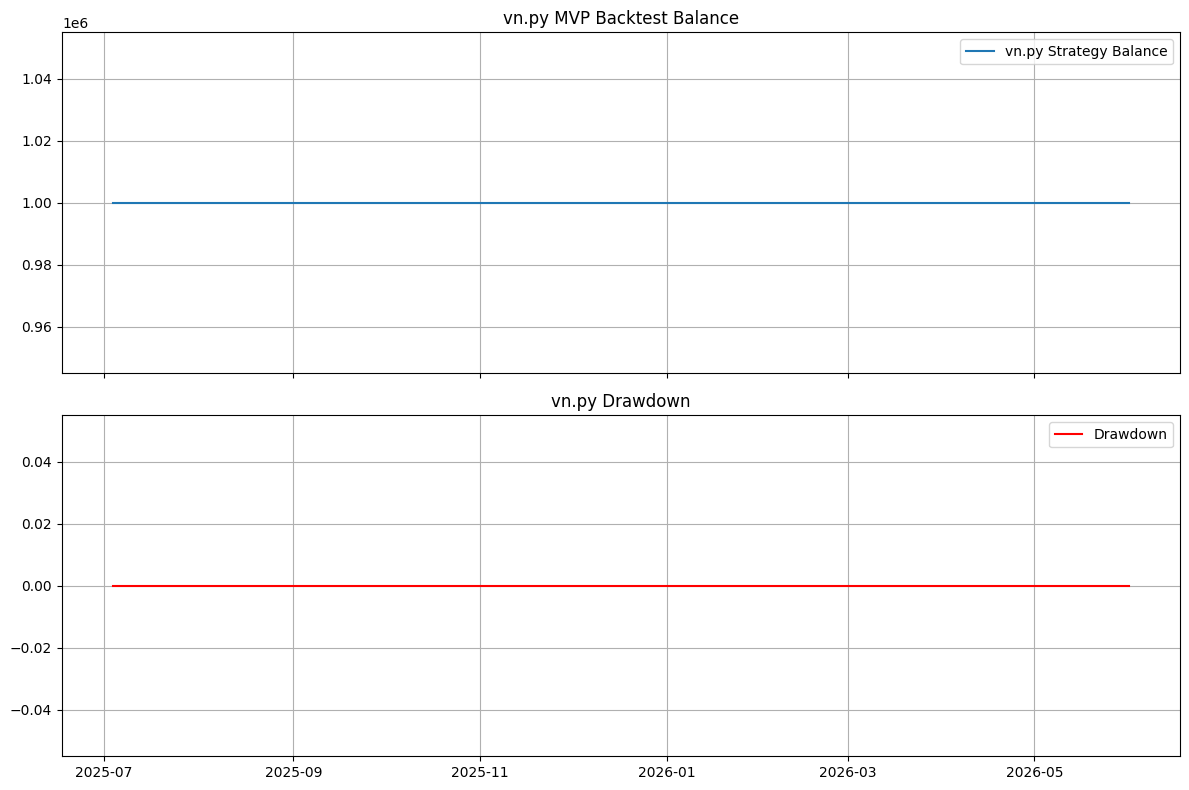

In [251]:
# 6) 画 vn.py 回测资金曲线和回撤。
import matplotlib.pyplot as plt

if daily_result is not None and not daily_result.empty and "balance" in daily_result.columns:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(daily_result.index, daily_result["balance"], label="vn.py Strategy Balance")
    axes[0].set_title("vn.py MVP Backtest Balance")
    axes[0].grid(True)
    axes[0].legend()

    if "drawdown" in daily_result.columns:
        axes[1].plot(daily_result.index, daily_result["drawdown"], color="red", label="Drawdown")
        axes[1].set_title("vn.py Drawdown")
        axes[1].grid(True)
        axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("daily_result is empty or has no balance column")
